# Method B FT Collapse Analysis

This notebook is the FT evidence log for the current bridge experiments. It refreshes run CSVs and Slurm logs from Unity, marks complete vs partial runs, compares Method A against Method B 256/512 variants, and interprets the logged metrics used to diagnose late-collapse and poor transfer.

In [1]:
from __future__ import annotations

import json
import os
import re
import shutil
import subprocess
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
pd.set_option('display.max_rows', 120)

HOST = 'bhuo_umass_edu@unity'
SSH_AUTH_SOCK = '/run/user/1000/gcr/ssh'
REMOTE_BASE = Path('/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs')
RUNS_ROOT = REMOTE_BASE / 'runs'
EXPECTED_FINAL_STEP = 1_500_000
EXPECTED_EVAL_ROWS = 11

def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / '.git').exists():
            return candidate
    return start.resolve()

REPO_ROOT = find_repo_root(Path.cwd())
CACHE_DIR = REPO_ROOT / 'output/jupyter-notebook/cache/method_b_ft_collapse_analysis'
ARTIFACT_DIR = REPO_ROOT / 'output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis'
LOG_DIR = ARTIFACT_DIR / 'logs'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

A_FT_ROOT = RUNS_ROOT / 'state_distilled_method_a_ft_grid_20260507_004541/runs/state_distilled_method_a_ft_grid'
A_EXTRA_GLOB = str(RUNS_ROOT / 'state_distilled_method_a_ft_extra_*/runs/state_distilled_method_a_ft_extra')
B256_PRE_ROOT = RUNS_ROOT / 'cross_modal_tcn_method_b_diag_20260506_232914/runs/cross_modal_tcn_method_b_diagnostic'
B512_PRE_ROOT = RUNS_ROOT / 'cross_modal_tcn_method_b_diag_20260506_205707/runs/cross_modal_tcn_method_b_diagnostic'
B256_SHORT_GLOB = str(RUNS_ROOT / 'cross_modal_tcn_b256_ft_pack_short_*/runs/cross_modal_tcn_b256_ft_pack_short')
B512_SHORT_GLOB = str(RUNS_ROOT / 'cross_modal_tcn_b512_ft_pack_short_*/runs/cross_modal_tcn_b512_ft_pack_short')
B256_NORMAL_GLOB = str(RUNS_ROOT / 'cross_modal_tcn_b256_ft_grid_20260507_*/runs/cross_modal_tcn_b256_ft_grid')
B512_NORMAL_GLOB = str(RUNS_ROOT / 'cross_modal_tcn_b512_ft_grid_20260507_*/runs/cross_modal_tcn_b512_ft_grid')

def run_ssh(command: str, timeout: int = 180) -> str:
    env = os.environ.copy()
    env['SSH_AUTH_SOCK'] = SSH_AUTH_SOCK
    proc = subprocess.run(
        ['ssh', '-o', 'ConnectTimeout=10', HOST, command],
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout,
        env=env,
        check=True,
    )
    return proc.stdout

def run_local(cmd: list[str], timeout: int = 180) -> subprocess.CompletedProcess[str]:
    env = os.environ.copy()
    env['SSH_AUTH_SOCK'] = SSH_AUTH_SOCK
    return subprocess.run(cmd, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, timeout=timeout, env=env, check=True)

def metric_col(df: pd.DataFrame, *candidates: str) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None

def finite_mean(series):
    values = pd.to_numeric(series, errors='coerce')
    return float(values.mean()) if values.notna().any() else np.nan


In [2]:
REMOTE_COLLECTOR = r'''
from pathlib import Path
import csv, glob, json, re, subprocess, time

RUNS_ROOT = Path('/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs')
A_FT_ROOT = RUNS_ROOT / 'state_distilled_method_a_ft_grid_20260507_004541/runs/state_distilled_method_a_ft_grid'
A_EXTRA_GLOB = str(RUNS_ROOT / 'state_distilled_method_a_ft_extra_*/runs/state_distilled_method_a_ft_extra')
B256_PRE_ROOT = RUNS_ROOT / 'cross_modal_tcn_method_b_diag_20260506_232914/runs/cross_modal_tcn_method_b_diagnostic'
B512_PRE_ROOT = RUNS_ROOT / 'cross_modal_tcn_method_b_diag_20260506_205707/runs/cross_modal_tcn_method_b_diagnostic'
B256_SHORT_GLOB = str(RUNS_ROOT / 'cross_modal_tcn_b256_ft_pack_short_*/runs/cross_modal_tcn_b256_ft_pack_short')
B512_SHORT_GLOB = str(RUNS_ROOT / 'cross_modal_tcn_b512_ft_pack_short_*/runs/cross_modal_tcn_b512_ft_pack_short')
B256_NORMAL_GLOB = str(RUNS_ROOT / 'cross_modal_tcn_b256_ft_grid_20260507_*/runs/cross_modal_tcn_b256_ft_grid')
B512_NORMAL_GLOB = str(RUNS_ROOT / 'cross_modal_tcn_b512_ft_grid_20260507_*/runs/cross_modal_tcn_b512_ft_grid')
EXPECTED_FINAL_STEP = 1500000
EXPECTED_EVAL_ROWS = 11

RUN_ROOTS = [
    {'method': 'Method A', 'source': 'A finished FT grid', 'root': A_FT_ROOT},
    {'method': 'Method B 256', 'source': 'B256 pretrain', 'root': B256_PRE_ROOT},
    {'method': 'Method B 512', 'source': 'B512 pretrain', 'root': B512_PRE_ROOT},
]
for root in glob.glob(A_EXTRA_GLOB):
    RUN_ROOTS.append({'method': 'Method A', 'source': 'A extra FT seeds', 'root': Path(root)})
for root in glob.glob(B256_SHORT_GLOB):
    RUN_ROOTS.append({'method': 'Method B 256', 'source': 'B256 short FT pack', 'root': Path(root)})
for root in glob.glob(B256_NORMAL_GLOB):
    RUN_ROOTS.append({'method': 'Method B 256', 'source': 'B256 normal FT', 'root': Path(root)})
for root in glob.glob(B512_NORMAL_GLOB):
    RUN_ROOTS.append({'method': 'Method B 512', 'source': 'B512 normal FT', 'root': Path(root)})
for root in glob.glob(B512_SHORT_GLOB):
    RUN_ROOTS.append({'method': 'Method B 512', 'source': 'B512 short FT pack', 'root': Path(root)})
seen = set()
unique_roots = []
for item in RUN_ROOTS:
    key = (item['method'], item['source'], str(item['root']))
    if key not in seen:
        seen.add(key)
        unique_roots.append(item)
RUN_ROOTS = unique_roots

def sh(cmd):
    return subprocess.run(cmd, shell=True, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT).stdout

def parse_task_seed(name):
    m = re.search(r'task(\d+)_seed(\d+)', name)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))

def parse_step_from_name(path):
    m = re.search(r'(?:training_state|params)_(\d+)\.pkl$', path.name)
    return int(m.group(1)) if m else None

def read_csv(path, method, source, phase, run_root):
    records = []
    if not path.exists():
        return records
    task, seed = parse_task_seed(path.parent.name)
    with path.open() as f:
        for row in csv.DictReader(f):
            rec = {
                'method': method,
                'source': source,
                'phase': phase,
                'run': path.parent.name,
                'run_root': str(run_root),
                'task': task,
                'seed': seed,
            }
            for key, value in row.items():
                try:
                    rec[key] = float(value)
                except (TypeError, ValueError):
                    rec[key] = value
            records.append(rec)
    return records

def best_eval_payload(run_dir, method, source):
    best_path = run_dir / 'best_eval.json'
    if not best_path.exists():
        return None
    try:
        best = json.loads(best_path.read_text())
    except Exception as exc:
        best = {'error': repr(exc)}
    task, seed = parse_task_seed(run_dir.name)
    best.update({'method': method, 'source': source, 'run': run_dir.name, 'task': task, 'seed': seed, 'best_eval_path': str(best_path)})
    return best

def summarize_run(run_dir, method, source, run_root):
    task, seed = parse_task_seed(run_dir.name)
    eval_path = run_dir / 'finetuning_eval.csv'
    train_path = run_dir / 'finetuning_train.csv'
    pretrain_path = run_dir / 'pretraining_train.csv'
    rows = []
    if eval_path.exists():
        with eval_path.open() as f:
            rows = list(csv.DictReader(f))
    def f(row, key):
        try:
            return float(row.get(key, 'nan'))
        except Exception:
            return float('nan')
    succ_key = None
    if rows:
        succ_key = 'evaluation/success' if 'evaluation/success' in rows[-1] else 'evaluation/episode.success'
    final_step = int(f(rows[-1], 'step')) if rows else None
    final_success = f(rows[-1], succ_key) if rows and succ_key else None
    final_return = f(rows[-1], 'evaluation/episode.return') if rows else None
    best_success = None
    best_step = None
    if rows and succ_key:
        best = max(rows, key=lambda r: f(r, succ_key))
        best_success = f(best, succ_key)
        best_step = int(f(best, 'step'))
    ckpt_dir = run_dir / 'checkpoints'
    ckpts = sorted(ckpt_dir.glob('training_state_*.pkl')) if ckpt_dir.exists() else []
    steps = [parse_step_from_name(p) for p in ckpts]
    steps = [s for s in steps if s is not None]
    latest_step = max(steps) if steps else None
    params = sorted(run_dir.glob('params_*.pkl'))
    param_steps = [parse_step_from_name(p) for p in params]
    status = 'no_eval'
    if rows:
        status = 'complete' if final_step is not None and final_step >= EXPECTED_FINAL_STEP and len(rows) >= EXPECTED_EVAL_ROWS else 'partial'
    return {
        'method': method,
        'source': source,
        'run': run_dir.name,
        'run_root': str(run_root),
        'task': task,
        'seed': seed,
        'eval_rows': len(rows),
        'train_rows': sum(1 for _ in open(train_path)) - 1 if train_path.exists() else 0,
        'pretrain_rows': sum(1 for _ in open(pretrain_path)) - 1 if pretrain_path.exists() else 0,
        'final_step': final_step,
        'best_step': best_step,
        'best_success': best_success,
        'final_success': final_success,
        'collapse': (best_success - final_success) if best_success is not None and final_success is not None else None,
        'final_return': final_return,
        'checkpoint_count': len(ckpts),
        'latest_checkpoint_step': latest_step,
        'param_checkpoint_count': len(params),
        'param_steps': [p for p in param_steps if p is not None],
        'status': status,
        'eval_path': str(eval_path) if eval_path.exists() else None,
        'train_path': str(train_path) if train_path.exists() else None,
        'checkpoint_dir': str(ckpt_dir) if ckpt_dir.exists() else None,
    }

def collect_run_root(root, method, source):
    root = Path(root)
    out = {'eval': [], 'train': [], 'pretrain': [], 'best': [], 'run_meta': []}
    if not root.exists():
        return out
    for run_dir in sorted([p for p in root.iterdir() if p.is_dir()]):
        out['eval'].extend(read_csv(run_dir / 'finetuning_eval.csv', method, source, 'finetuning', root))
        out['train'].extend(read_csv(run_dir / 'finetuning_train.csv', method, source, 'finetuning', root))
        out['pretrain'].extend(read_csv(run_dir / 'pretraining_train.csv', method, source, 'pretraining', root))
        best = best_eval_payload(run_dir, method, source)
        if best is not None:
            out['best'].append(best)
        out['run_meta'].append(summarize_run(run_dir, method, source, root))
    return out

def merge_dicts(items):
    merged = {'eval': [], 'train': [], 'pretrain': [], 'best': [], 'run_meta': []}
    for item in items:
        for key in merged:
            merged[key].extend(item[key])
    return merged

def log_manifest_for_roots(run_roots):
    rows = []
    for item in run_roots:
        root = Path(item['root'])
        candidates = [root.parent.parent / 'slurm', root.parent / 'slurm', root / 'slurm']
        for slurm_dir in candidates:
            if not slurm_dir.exists() or not slurm_dir.is_dir():
                continue
            for log_path in sorted(slurm_dir.glob('*')):
                if not log_path.is_file():
                    continue
                if log_path.suffix not in {'.out', '.err', '.log', '.sbatch'}:
                    continue
                try:
                    stat = log_path.stat()
                except OSError:
                    continue
                rows.append({
                    'method': item['method'],
                    'source': item['source'],
                    'run_root': str(root),
                    'remote_log_path': str(log_path),
                    'remote_log_name': log_path.name,
                    'remote_log_size': stat.st_size,
                    'remote_log_mtime': stat.st_mtime,
                })
    by_path = {}
    for row in rows:
        by_path[row['remote_log_path']] = row
    return list(by_path.values())

roots = [collect_run_root(item['root'], item['method'], item['source']) for item in RUN_ROOTS]
merged = merge_dicts(roots)
job_filter = '56891473|56901975|56931083|569026|569027|569028|569029|57079738|57079806|571107|tcn|sd-infom|state_distilled_method_a_ft_extra'
snapshot = {
    'collected_at_utc': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
    'slurm_status': sh("squeue -u bhuo_umass_edu -o '%.18i %.9P %.12q %.30j %.8T %.12M %.12l %.22R %.12b' | grep -E 'JOBID|" + job_filter + "'"),
    'recent_sacct': sh("sacct -u bhuo_umass_edu --starttime=2026-05-07T00:00:00 --format=JobID,JobName%38,Partition,QOS,State,ExitCode,Elapsed,Timelimit,AllocTRES%45,NodeList%24 -P | grep -E 'JobID|tcn|state_distilled|sd-infom' | tail -220"),
    'run_roots': [{'method': item['method'], 'source': item['source'], 'root': str(item['root']), 'exists': Path(item['root']).exists()} for item in RUN_ROOTS],
    'log_manifest': log_manifest_for_roots(RUN_ROOTS),
    **merged,
}
print(json.dumps(snapshot))
'''
raw = run_ssh("python - <<'PY'\n" + REMOTE_COLLECTOR + "\nPY", timeout=240)
snapshot = json.loads(raw)
(CACHE_DIR / 'snapshot.json').write_text(json.dumps(snapshot, indent=2, sort_keys=True) + '\n')
print('Collected at', snapshot['collected_at_utc'])
print('eval rows', len(snapshot['eval']), 'train rows', len(snapshot['train']), 'pretrain rows', len(snapshot['pretrain']))
print('run meta rows', len(snapshot['run_meta']), 'log files', len(snapshot['log_manifest']))
print(snapshot['slurm_status'])


Collected at 2026-05-08T14:20:55Z
eval rows 517 train rows 23603 pretrain rows 405
run meta rows 49 log files 137
             JOBID PARTITION          QOS                           NAME    STATE         TIME   TIME_LIMIT       NODELIST(REASON) TRES_PER_NOD



In [3]:
eval_df = pd.DataFrame(snapshot['eval'])
train_df = pd.DataFrame(snapshot['train'])
pre_df = pd.DataFrame(snapshot['pretrain'])
best_df = pd.DataFrame(snapshot['best'])
run_meta_df = pd.DataFrame(snapshot['run_meta'])
run_roots_df = pd.DataFrame(snapshot['run_roots'])
log_manifest_df = pd.DataFrame(snapshot['log_manifest'])

for df in [eval_df, train_df, pre_df, run_meta_df]:
    if not df.empty and 'step' in df:
        df['step'] = pd.to_numeric(df['step'], errors='coerce').astype('Int64')
    if not df.empty and 'task' in df:
        df['task'] = pd.to_numeric(df['task'], errors='coerce').astype('Int64')
    if not df.empty and 'seed' in df:
        df['seed'] = pd.to_numeric(df['seed'], errors='coerce').astype('Int64')

SUCCESS = metric_col(eval_df, 'evaluation/success', 'evaluation/episode.success')
RETURN = metric_col(eval_df, 'evaluation/episode.return')
print('success column:', SUCCESS, 'return column:', RETURN)
print('snapshot:', snapshot['collected_at_utc'])
display(run_roots_df)
display(run_meta_df.sort_values(['method','source','task','seed','run']).head(30) if not run_meta_df.empty else pd.DataFrame({'status':['no run metadata']}))

success column: evaluation/success return column: evaluation/episode.return
snapshot: 2026-05-08T14:20:55Z


,method,source,root,exists
0,Method A,A finished FT grid,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,True
1,Method B 256,B256 pretrain,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,True
2,Method B 512,B512 pretrain,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,True
3,Method A,A extra FT seeds,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,True
4,Method B 256,B256 short FT pack,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,True
5,Method B 512,B512 normal FT,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,True
6,Method B 512,B512 short FT pack,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,True


,method,source,run,run_root,task,seed,eval_rows,train_rows,pretrain_rows,final_step,best_step,best_success,final_success,collapse,final_return,checkpoint_count,latest_checkpoint_step,param_checkpoint_count,param_steps,status,eval_path,train_path,checkpoint_dir
11,Method A,A extra FT seeds,task1_seed2_1000kpre_500kft_from_method_a_1m_e...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,1,2,11,500,0,1500000.0,1050000.0,0.74,0.44,0.30,-163.20,4,1500000,2,"[1000001, 1050000]",complete,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...
12,Method A,A extra FT seeds,task1_seed3_1000kpre_500kft_from_method_a_1m_e...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,1,3,11,500,0,1500000.0,1150000.0,0.44,0.00,0.44,-200.00,4,1500000,3,"[1000001, 1100000, 1150000]",complete,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...
13,Method A,A extra FT seeds,task1_seed4_1000kpre_500kft_from_method_a_1m_e...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,1,4,11,500,0,1500000.0,1050000.0,0.68,0.00,0.68,-200.00,4,1500000,2,"[1000001, 1050000]",complete,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...
14,Method A,A extra FT seeds,task1_seed5_1000kpre_500kft_from_method_a_1m_e...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,1,5,11,500,0,1500000.0,1450000.0,0.80,0.74,0.06,-117.84,4,1500000,5,"[1000001, 1100000, 1150000, 1200000, 1450000]",complete,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...
15,Method A,A extra FT seeds,task4_seed2_1000kpre_500kft_from_method_a_1m_e...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,4,2,11,500,0,1500000.0,1200000.0,0.64,0.00,0.64,-200.00,4,1500000,4,"[1000001, 1050000, 1150000, 1200000]",complete,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...
16,Method A,A extra FT seeds,task4_seed3_1000kpre_500kft_from_method_a_1m_e...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,4,3,11,500,0,1500000.0,1150000.0,0.24,0.00,0.24,-200.00,4,1500000,3,"[1000001, 1050000, 1150000]",complete,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...
17,Method A,A extra FT seeds,task4_seed4_1000kpre_500kft_from_method_a_1m_e...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,4,4,11,500,0,1500000.0,1300000.0,0.46,0.42,0.04,-170.54,4,1500000,5,"[1000001, 1050000, 1100000, 1200000, 1300000]",complete,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...
18,Method A,A extra FT seeds,task4_seed5_1000kpre_500kft_from_method_a_1m_e...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,4,5,11,500,0,1500000.0,1100000.0,0.26,0.00,0.26,-200.00,4,1500000,3,"[1000001, 1050000, 1100000]",complete,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...
0,Method A,A finished FT grid,task1_seed1_1000kpre_500kft_from_method_a_1m,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,1,1,11,500,0,1500000.0,1050000.0,0.62,0.00,0.62,-200.00,5,1500000,2,"[1000001, 1050000]",complete,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...
1,Method A,A finished FT grid,task2_seed0_1000kpre_500kft_from_method_a_1m,/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/in...,2,0,11,500,0,1500000.0,1200000.0,0.24,0.00,0.24,-200.00,5,1500000,4,"[1000001, 1100000, 1150000, 1200000]",complete,/work/pi_m

## Status Reading

The notebook distinguishes completed and partial FT runs. A completed FT run reaches step `1,500,000` with 11 eval rows; partial runs are shown in tables and curves but excluded from complete-only aggregates unless explicitly labeled.

In [4]:
if run_meta_df.empty:
    summary = pd.DataFrame({'status': ['No run metadata available.']})
else:
    summary = run_meta_df.copy()
    for col in ['eval_rows','train_rows','pretrain_rows','final_step','best_step','best_success','final_success','collapse','final_return','checkpoint_count','latest_checkpoint_step']:
        if col in summary.columns:
            summary[col] = pd.to_numeric(summary[col], errors='coerce')
    summary = summary[summary['eval_rows'].fillna(0) > 0].copy()
    summary['is_complete'] = (summary['status'] == 'complete')
    summary['is_partial'] = (summary['status'] == 'partial')
    preferred_sources = {
        'A finished FT grid',
        'B256 short FT pack',
        'B512 normal FT',
        'B512 short FT pack',
    }
    summary['is_primary_source'] = summary['source'].isin(preferred_sources)
    summary = summary.sort_values(['method','source','task','seed','run'])

summary_path = ARTIFACT_DIR / 'ft_summary.csv'
summary.to_csv(summary_path, index=False)
display(summary[['method','source','run','task','seed','status','eval_rows','final_step','best_step','best_success','final_success','collapse','final_return','checkpoint_count','latest_checkpoint_step']])
print('wrote', summary_path)

,method,source,run,task,seed,status,eval_rows,final_step,best_step,best_success,final_success,collapse,final_return,checkpoint_count,latest_checkpoint_step
11,Method A,A extra FT seeds,task1_seed2_1000kpre_500kft_from_method_a_1m_e...,1,2,complete,11,1500000.0,1050000.0,0.74,0.44,0.30,-163.20,4,1500000
12,Method A,A extra FT seeds,task1_seed3_1000kpre_500kft_from_method_a_1m_e...,1,3,complete,11,1500000.0,1150000.0,0.44,0.00,0.44,-200.00,4,1500000
13,Method A,A extra FT seeds,task1_seed4_1000kpre_500kft_from_method_a_1m_e...,1,4,complete,11,1500000.0,1050000.0,0.68,0.00,0.68,-200.00,4,1500000
14,Method A,A extra FT seeds,task1_seed5_1000kpre_500kft_from_method_a_1m_e...,1,5,complete,11,1500000.0,1450000.0,0.80,0.74,0.06,-117.84,4,1500000
15,Method A,A extra FT seeds,task4_seed2_1000kpre_500kft_from_method_a_1m_e...,4,2,complete,11,1500000.0,1200000.0,0.64,0.00,0.64,-200.00,4,1500000
16,Method A,A extra FT seeds,task4_seed3_1000kpre_500kft_from_method_a_1m_e...,4,3,complete,11,1500000.0,1150000.0,0.24,0.00,0.24,-200.00,4,1500000
17,Method A,A extra FT seeds,task4_seed4_1000kpre_500kft_from_method_a_1m_e...,4,4,complete,11,1500000.0,1300000.0,0.46,0.42,0.04,-170.54,4,1500000
18,Method A,A extra FT seeds,task4_seed5_1000kpre_500kft_from_method_a_1m_e...,4,5,complete,11,1500000.0,1100000.0,0.26,0.00,0.26,-200.00,4,1500000
0,Method A,A finished FT grid,task1_seed1_1000kpre_500kft_from_method_a_1m,1,1,complete,11,1500000.0,1050000.0,0.62,0.00,0.62,-200.00,5,1500000
1,Method A,A finished FT grid,task2_seed0_1000kpre_500kft_from_method_a_1m,2,0,complete,11,1500000.0,1200000.0,0.24,0.00,0.24,-200.00,5,1500000


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_summary.csv


In [5]:
if not summary.empty:
    complete_summary = summary[summary['is_complete'] & summary['is_primary_source']].copy()
    partial_summary = summary[summary['is_partial'] & summary['is_primary_source']].copy()
    aggregate_cols = dict(
        n_runs=('run', 'count'),
        mean_best_success=('best_success', 'mean'),
        max_best_success=('best_success', 'max'),
        mean_final_success=('final_success', 'mean'),
        max_final_success=('final_success', 'max'),
        mean_collapse=('collapse', 'mean'),
        mean_final_return=('final_return', 'mean'),
    )
    method_overall = complete_summary.groupby(['method','source'], dropna=False).agg(**aggregate_cols).reset_index().sort_values(['method','source'])
    method_task = complete_summary.groupby(['method','source','task'], dropna=False).agg(**aggregate_cols).reset_index().sort_values(['method','source','task'])
    partial_by_source = partial_summary.groupby(['method','source'], dropna=False).agg(
        n_partial=('run','count'),
        max_seen_step=('final_step','max'),
        mean_seen_success=('final_success','mean'),
        max_seen_success=('best_success','max'),
    ).reset_index() if not partial_summary.empty else pd.DataFrame()
else:
    complete_summary = pd.DataFrame()
    partial_summary = pd.DataFrame()
    method_overall = pd.DataFrame()
    method_task = pd.DataFrame()
    partial_by_source = pd.DataFrame()

method_overall_path = ARTIFACT_DIR / 'ft_aggregate_by_method.csv'
method_task_path = ARTIFACT_DIR / 'ft_aggregate_by_method_task.csv'
partial_path = ARTIFACT_DIR / 'ft_partial_runs.csv'
method_overall.to_csv(method_overall_path, index=False)
method_task.to_csv(method_task_path, index=False)
partial_summary.to_csv(partial_path, index=False)

display(method_overall)
display(method_task)
if not partial_by_source.empty:
    display(partial_by_source)
print('wrote', method_overall_path)
print('wrote', method_task_path)
print('wrote', partial_path)


,method,source,n_runs,mean_best_success,max_best_success,mean_final_success,max_final_success,mean_collapse,mean_final_return
0,Method A,A finished FT grid,9,0.433333,0.66,0.137778,0.48,0.295556,-188.180
1,Method B 256,B256 short FT pack,10,0.124000,0.22,0.076000,0.18,0.048000,-194.024
2,Method B 512,B512 normal FT,10,0.120000,0.18,0.036000,0.08,0.084000,-197.414
3,Method B 512,B512 short FT pack,10,0.138000,0.26,0.060000,0.20,0.078000,-194.848


,method,source,task,n_runs,mean_best_success,max_best_success,mean_final_success,max_final_success,mean_collapse,mean_final_return
0,Method A,A finished FT grid,1,1,0.62,0.62,0.00,0.00,0.62,-200.00
1,Method A,A finished FT grid,2,2,0.17,0.24,0.00,0.00,0.17,-200.00
2,Method A,A finished FT grid,3,2,0.36,0.36,0.18,0.36,0.18,-183.28
3,Method A,A finished FT grid,4,2,0.63,0.66,0.44,0.48,0.19,-163.53
4,Method A,A finished FT grid,5,2,0.48,0.56,0.00,0.00,0.48,-200.00
5,Method B 256,B256 short FT pack,1,2,0.17,0.18,0.08,0.12,0.09,-193.11
6,Method B 256,B256 short FT pack,2,2,0.12,0.12,0.08,0.12,0.04,-191.23
7,Method B 256,B256 short FT pack,3,2,0.20,0.22,0.14,0.18,0.06,-191.43
8,Method B 256,B256 short FT pack,4,2,0.07,0.08,0.07,0.08,0.00,-195.16
9,Method B 256,B256 short FT pack,5,2,0.06,0.08,0.01,0.02,0.05,-199.19


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_aggregate_by_method.csv
wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_aggregate_by_method_task.csv
wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_partial_runs.csv


## Paper-Aligned Metrics

The paper reports end-of-fine-tuning OGBench success, not best checkpoint success. For these runs the paper-style metric is the mean success over total steps `1,400,000`, `1,450,000`, and `1,500,000`; best success and collapse remain diagnostics.


,method,source,run,task,seed,paper_window_rows,paper_window_success,paper_target_success,paper_delta,best_step,best_success,final_step,final_success,collapse,complete_for_paper_metric
0,Method A,A extra FT seeds,task1_seed2_1000kpre_500kft_from_method_a_1m_e...,1,2,3,0.266667,0.925,-0.658333,1050000,0.74,1500000,0.44,0.30,True
1,Method A,A extra FT seeds,task1_seed3_1000kpre_500kft_from_method_a_1m_e...,1,3,3,0.006667,0.925,-0.918333,1150000,0.44,1500000,0.00,0.44,True
2,Method A,A extra FT seeds,task1_seed4_1000kpre_500kft_from_method_a_1m_e...,1,4,3,0.000000,0.925,-0.925000,1050000,0.68,1500000,0.00,0.68,True
3,Method A,A extra FT seeds,task1_seed5_1000kpre_500kft_from_method_a_1m_e...,1,5,3,0.680000,0.925,-0.245000,1450000,0.80,1500000,0.74,0.06,True
4,Method A,A extra FT seeds,task4_seed2_1000kpre_500kft_from_method_a_1m_e...,4,2,3,0.000000,0.915,-0.915000,1200000,0.64,1500000,0.00,0.64,True
5,Method A,A extra FT seeds,task4_seed3_1000kpre_500kft_from_method_a_1m_e...,4,3,3,0.000000,0.915,-0.915000,1150000,0.24,1500000,0.00,0.24,True
6,Method A,A extra FT seeds,task4_seed4_1000kpre_500kft_from_method_a_1m_e...,4,4,3,0.306667,0.915,-0.608333,1300000,0.46,1500000,0.42,0.04,True
7,Method A,A extra FT seeds,task4_seed5_1000kpre_500kft_from_method_a_1m_e...,4,5,3,0.020000,0.915,-0.895000,1100000,0.26,1500000,0.00,0.26,True
8,Method A,A finished FT grid,task1_seed1_1000kpre_500kft_from_method_a_1m,1,1,3,0.000000,0.925,-0.925000,1050000,0.62,1500000,0.00,0.62,True
9,Method A,A finished FT grid,task2_seed0_1000kpre_500kft_from_method_a_1m,2,0,3,0.026667,0.784,-0.757333,1200000,0.24,1500000,0.00,0.24,True


,method,source,n_runs,mean_paper_success,std_paper_success,mean_best_success,mean_final_success,mean_collapse
0,Method A,A extra FT seeds,8,0.16000,0.245880,0.532500,0.200000,0.332500
1,Method A,A finished FT grid,9,0.13037,0.191750,0.433333,0.137778,0.295556
2,Method B 256,B256 short FT pack,10,0.06200,0.039634,0.124000,0.076000,0.048000
3,Method B 512,B512 normal FT,10,0.03200,0.027541,0.120000,0.036000,0.084000
4,Method B 512,B512 short FT pack,10,0.04800,0.040588,0.138000,0.060000,0.078000


,method,source,task,n_runs,mean_paper_success,std_paper_success,max_paper_success,paper_target_success,mean_paper_delta,mean_best_success,mean_final_success,mean_collapse
0,Method A,A extra FT seeds,1,4,0.238333,0.319554,0.680000,0.925,-0.686667,0.665,0.295,0.370
1,Method A,A extra FT seeds,4,4,0.081667,0.150296,0.306667,0.915,-0.833333,0.400,0.105,0.295
2,Method A,A finished FT grid,1,1,0.000000,NaN,0.000000,0.925,-0.925000,0.620,0.000,0.620
3,Method A,A finished FT grid,2,2,0.013333,0.018856,0.026667,0.784,-0.770667,0.170,0.000,0.170
4,Method A,A finished FT grid,3,2,0.123333,0.174420,0.246667,0.564,-0.440667,0.360,0.180,0.180
5,Method A,A finished FT grid,4,2,0.433333,0.094281,0.500000,0.915,-0.481667,0.630,0.440,0.190
6,Method A,A finished FT grid,5,2,0.016667,0.023570,0.033333,0.700,-0.683333,0.480,0.000,0.480
7,Method B 256,B256 short FT pack,1,2,0.076667,0.023570,0.093333,0.925,-0.848333,0.170,0.080,0.090
8,Method B 256,B256 short FT pack,2,2,0.080000,0.028284,0.100000,0.784,-0.704000,0.120,0.080,0.040
9,Method B 256,B256 short FT pack,3,2,0.106667,0.028284,0.126667,0.564,-0.457333,0.200,0.140,0.060


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_paper_window_metrics.csv
wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_paper_window_by_method.csv
wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_paper_window_by_task.csv


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/paper_window_success_vs_target.png


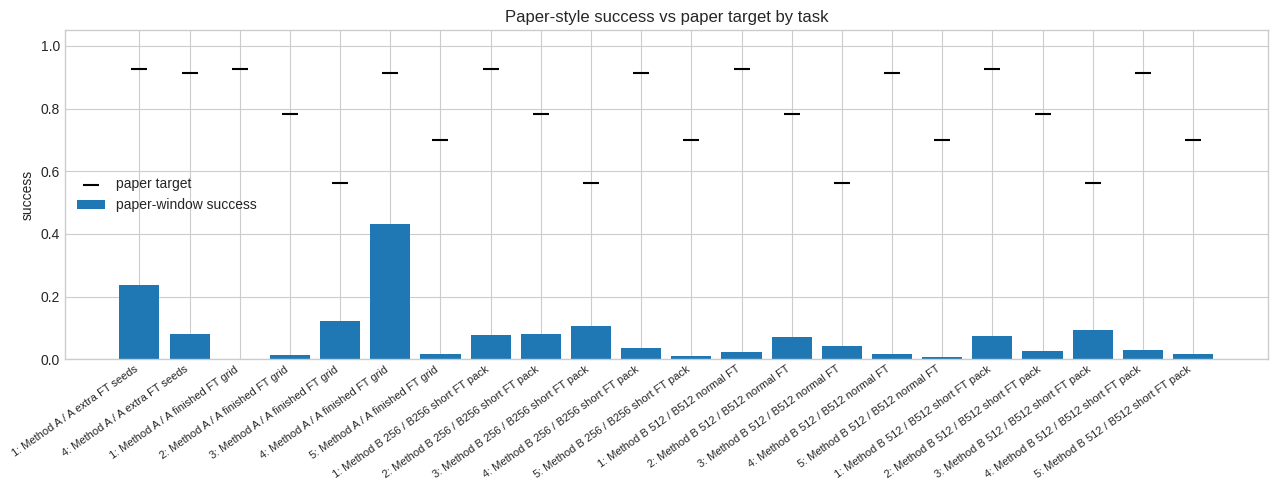

In [6]:
PAPER_WINDOW_STEPS = [1_400_000, 1_450_000, 1_500_000]
PAPER_TARGETS = {1: 0.925, 2: 0.784, 3: 0.564, 4: 0.915, 5: 0.700}
PRIMARY_SOURCES = ['A finished FT grid', 'A extra FT seeds', 'B256 short FT pack', 'B512 normal FT', 'B512 short FT pack']

paper_rows = []
if not eval_df.empty and SUCCESS:
    for keys, g in eval_df[eval_df['source'].isin(PRIMARY_SOURCES)].groupby(['method','source','run','task','seed'], dropna=False):
        method, source, run, task, seed = keys
        g = g.sort_values('step').copy()
        g['step_numeric'] = pd.to_numeric(g['step'], errors='coerce')
        g['success_numeric'] = pd.to_numeric(g[SUCCESS], errors='coerce')
        window = g[g['step_numeric'].isin(PAPER_WINDOW_STEPS)]
        final_row = g.tail(1)
        best_idx = g['success_numeric'].idxmax() if g['success_numeric'].notna().any() else None
        best_row = g.loc[[best_idx]] if best_idx is not None else pd.DataFrame()
        task_int = int(task) if pd.notna(task) else None
        target = PAPER_TARGETS.get(task_int, np.nan)
        paper_success = float(window['success_numeric'].mean()) if not window.empty else np.nan
        paper_rows.append({
            'method': method,
            'source': source,
            'run': run,
            'task': task_int,
            'seed': int(seed) if pd.notna(seed) else None,
            'paper_window_rows': int(len(window)),
            'paper_window_success': paper_success,
            'paper_target_success': target,
            'paper_delta': paper_success - target if np.isfinite(paper_success) and np.isfinite(target) else np.nan,
            'best_step': int(best_row['step_numeric'].iloc[0]) if not best_row.empty else np.nan,
            'best_success': float(best_row['success_numeric'].iloc[0]) if not best_row.empty else np.nan,
            'final_step': int(final_row['step_numeric'].iloc[0]) if not final_row.empty else np.nan,
            'final_success': float(final_row['success_numeric'].iloc[0]) if not final_row.empty else np.nan,
            'collapse': float(best_row['success_numeric'].iloc[0] - final_row['success_numeric'].iloc[0]) if not best_row.empty and not final_row.empty else np.nan,
            'complete_for_paper_metric': int(len(window)) == len(PAPER_WINDOW_STEPS),
        })

paper_metric_df = pd.DataFrame(paper_rows).sort_values(['method','source','task','seed','run']) if paper_rows else pd.DataFrame()
paper_metric_path = ARTIFACT_DIR / 'ft_paper_window_metrics.csv'
paper_metric_df.to_csv(paper_metric_path, index=False)

if not paper_metric_df.empty:
    complete_paper_df = paper_metric_df[paper_metric_df['complete_for_paper_metric']].copy()
    paper_by_method = complete_paper_df.groupby(['method','source'], dropna=False).agg(
        n_runs=('run','count'),
        mean_paper_success=('paper_window_success','mean'),
        std_paper_success=('paper_window_success','std'),
        mean_best_success=('best_success','mean'),
        mean_final_success=('final_success','mean'),
        mean_collapse=('collapse','mean'),
    ).reset_index().sort_values(['method','source'])
    paper_by_task = complete_paper_df.groupby(['method','source','task'], dropna=False).agg(
        n_runs=('run','count'),
        mean_paper_success=('paper_window_success','mean'),
        std_paper_success=('paper_window_success','std'),
        max_paper_success=('paper_window_success','max'),
        paper_target_success=('paper_target_success','first'),
        mean_paper_delta=('paper_delta','mean'),
        mean_best_success=('best_success','mean'),
        mean_final_success=('final_success','mean'),
        mean_collapse=('collapse','mean'),
    ).reset_index().sort_values(['method','source','task'])
else:
    complete_paper_df = pd.DataFrame()
    paper_by_method = pd.DataFrame()
    paper_by_task = pd.DataFrame()

paper_by_method_path = ARTIFACT_DIR / 'ft_paper_window_by_method.csv'
paper_by_task_path = ARTIFACT_DIR / 'ft_paper_window_by_task.csv'
paper_by_method.to_csv(paper_by_method_path, index=False)
paper_by_task.to_csv(paper_by_task_path, index=False)

display(paper_metric_df)
display(paper_by_method)
display(paper_by_task)
print('wrote', paper_metric_path)
print('wrote', paper_by_method_path)
print('wrote', paper_by_task_path)

if not paper_by_task.empty:
    plot = paper_by_task[paper_by_task['source'].isin(PRIMARY_SOURCES)].copy()
    plot['label'] = plot['method'] + ' / ' + plot['source']
    fig, ax = plt.subplots(figsize=(13, 5))
    x_labels = [f'{row.task}: {row.label}' for row in plot.itertuples()]
    x = np.arange(len(plot))
    ax.bar(x, plot['mean_paper_success'], label='paper-window success')
    ax.scatter(x, plot['paper_target_success'], color='black', marker='_', s=140, label='paper target')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=35, ha='right', fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('success')
    ax.set_title('Paper-style success vs paper target by task')
    ax.legend()
    fig.tight_layout()
    path = ARTIFACT_DIR / 'paper_window_success_vs_target.png'
    fig.savefig(path, dpi=160)
    print('wrote', path)


## Seed Coverage And Collapse Timing

This section makes the evidence gaps explicit. It distinguishes completed paper-window rows from partial rows, and records when each run first reaches best success and when late decay begins.


In [7]:
if not paper_metric_df.empty:
    coverage_df = paper_metric_df.copy()
    coverage_df['status'] = np.where(coverage_df['complete_for_paper_metric'], 'paper-complete', 'partial-or-missing-window')
    coverage_df['seed_label'] = 's' + coverage_df['seed'].astype('Int64').astype(str)
    coverage_pivot = coverage_df.pivot_table(
        index=['method','source','task'],
        columns='seed_label',
        values='status',
        aggfunc='first',
        fill_value='missing',
    ).reset_index()
else:
    coverage_df = pd.DataFrame()
    coverage_pivot = pd.DataFrame()

collapse_rows = []
if not eval_df.empty and SUCCESS:
    for keys, g in eval_df[eval_df['source'].isin(PRIMARY_SOURCES)].groupby(['method','source','run','task','seed'], dropna=False):
        method, source, run, task, seed = keys
        g = g.sort_values('step').copy()
        g['step_numeric'] = pd.to_numeric(g['step'], errors='coerce')
        g['success_numeric'] = pd.to_numeric(g[SUCCESS], errors='coerce')
        if g.empty or not g['success_numeric'].notna().any():
            continue
        best_idx = g['success_numeric'].idxmax()
        best_step = int(g.loc[best_idx, 'step_numeric'])
        best_success = float(g.loc[best_idx, 'success_numeric'])
        after_best = g[g['step_numeric'] > best_step]
        below_half = after_best[after_best['success_numeric'] <= 0.5 * best_success] if best_success > 0 else pd.DataFrame()
        first_half_collapse_step = int(below_half['step_numeric'].iloc[0]) if not below_half.empty else np.nan
        row = {
            'method': method,
            'source': source,
            'run': run,
            'task': int(task) if pd.notna(task) else None,
            'seed': int(seed) if pd.notna(seed) else None,
            'best_step': best_step,
            'best_success': best_success,
            'final_step': int(g['step_numeric'].iloc[-1]),
            'final_success': float(g['success_numeric'].iloc[-1]),
            'collapse': float(best_success - g['success_numeric'].iloc[-1]),
            'first_step_after_best_below_half_best': first_half_collapse_step,
        }
        for step in PAPER_WINDOW_STEPS:
            vals = g.loc[g['step_numeric'] == step, 'success_numeric']
            row[f'success_{step}'] = float(vals.iloc[0]) if not vals.empty else np.nan
        collapse_rows.append(row)
collapse_timing_df = pd.DataFrame(collapse_rows).sort_values(['method','source','task','seed','run']) if collapse_rows else pd.DataFrame()

coverage_path = ARTIFACT_DIR / 'ft_seed_coverage.csv'
collapse_path = ARTIFACT_DIR / 'ft_collapse_timing.csv'
coverage_df.to_csv(coverage_path, index=False)
collapse_timing_df.to_csv(collapse_path, index=False)

display(coverage_pivot)
display(collapse_timing_df)
print('wrote', coverage_path)
print('wrote', collapse_path)


seed_label,method,source,task,s0,s1,s2,s3,s4,s5
0,Method A,A extra FT seeds,1,missing,missing,paper-complete,paper-complete,paper-complete,paper-complete
1,Method A,A extra FT seeds,4,missing,missing,paper-complete,paper-complete,paper-complete,paper-complete
2,Method A,A finished FT grid,1,missing,paper-complete,missing,missing,missing,missing
3,Method A,A finished FT grid,2,paper-complete,paper-complete,missing,missing,missing,missing
4,Method A,A finished FT grid,3,paper-complete,paper-complete,missing,missing,missing,missing
5,Method A,A finished FT grid,4,paper-complete,paper-complete,missing,missing,missing,missing
6,Method A,A finished FT grid,5,paper-complete,paper-complete,missing,missing,missing,missing
7,Method B 256,B256 short FT pack,1,paper-complete,paper-complete,missing,missing,missing,missing
8,Method B 256,B256 short FT pack,2,paper-complete,paper-complete,missing,missing,missing,missing
9,Method B 256,B256 short FT pack,3,paper-complete,paper-complete,missing,missing,missing,missing


,method,source,run,task,seed,best_step,best_success,final_step,final_success,collapse,first_step_after_best_below_half_best,success_1400000,success_1450000,success_1500000
0,Method A,A extra FT seeds,task1_seed2_1000kpre_500kft_from_method_a_1m_e...,1,2,1050000,0.74,1500000,0.44,0.30,1100000.0,0.12,0.24,0.44
1,Method A,A extra FT seeds,task1_seed3_1000kpre_500kft_from_method_a_1m_e...,1,3,1150000,0.44,1500000,0.00,0.44,1250000.0,0.02,0.00,0.00
2,Method A,A extra FT seeds,task1_seed4_1000kpre_500kft_from_method_a_1m_e...,1,4,1050000,0.68,1500000,0.00,0.68,1100000.0,0.00,0.00,0.00
3,Method A,A extra FT seeds,task1_seed5_1000kpre_500kft_from_method_a_1m_e...,1,5,1450000,0.80,1500000,0.74,0.06,NaN,0.50,0.80,0.74
4,Method A,A extra FT seeds,task4_seed2_1000kpre_500kft_from_method_a_1m_e...,4,2,1200000,0.64,1500000,0.00,0.64,1300000.0,0.00,0.00,0.00
5,Method A,A extra FT seeds,task4_seed3_1000kpre_500kft_from_method_a_1m_e...,4,3,1150000,0.24,1500000,0.00,0.24,1250000.0,0.00,0.00,0.00
6,Method A,A extra FT seeds,task4_seed4_1000kpre_500kft_from_method_a_1m_e...,4,4,1300000,0.46,1500000,0.42,0.04,1350000.0,0.10,0.40,0.42
7,Method A,A extra FT seeds,task4_seed5_1000kpre_500kft_from_method_a_1m_e...,4,5,1100000,0.26,1500000,0.00,0.26,1300000.0,0.06,0.00,0.00
8,Method A,A finished FT grid,task1_seed1_1000kpre_500kft_from_method_a_1m,1,1,1050000,0.62,1500000,0.00,0.62,1100000.0,0.00,0.00,0.00
9,Method A,A finished FT grid,task2_seed0_1000kpre_500kft_from_method_a_1m,2,0,1200000,0.24,1500000,0.00,0.24,1250000.0,0.08,0.00,0.00


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_seed_coverage.csv
wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_collapse_timing.csv


## Evaluation Metrics

Primary paper-aligned metric is OGBench success averaged over the late fine-tuning window (`1.4M`, `1.45M`, `1.5M` total steps). `final_success`, `best_success`, and `collapse` are diagnostics. `episode.return` and `episode.length` are secondary behavioral signals: less negative return and shorter length usually indicate faster success or partial progress. `control`, `qpos`, and `qvel` are sanity/debug metrics and should not be used as headline performance.


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/eval_success_curves.png


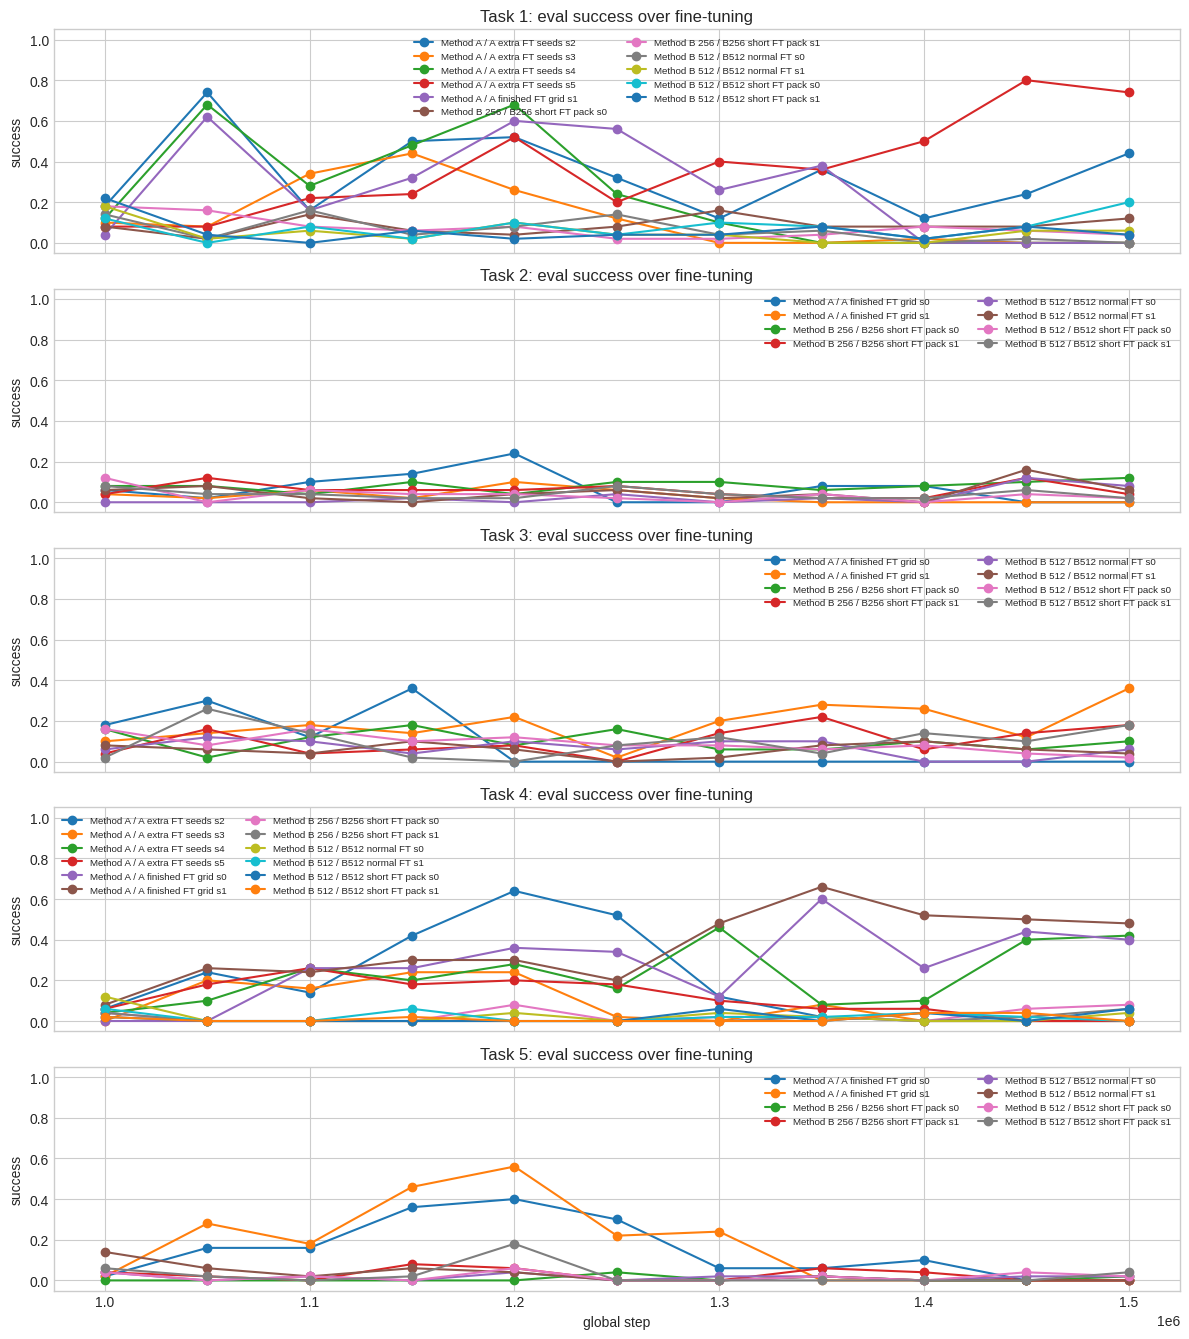

In [8]:
if not eval_df.empty and SUCCESS:
    plot_df = eval_df.copy()
    plot_df['source_label'] = plot_df['method'] + ' / ' + plot_df['source']
    primary_sources = ['A finished FT grid', 'A extra FT seeds', 'B256 short FT pack', 'B512 normal FT', 'B512 short FT pack']
    plot_df = plot_df[plot_df['source'].isin(primary_sources)]
    tasks = sorted([int(x) for x in plot_df['task'].dropna().unique()])
    fig, axes = plt.subplots(len(tasks), 1, figsize=(12, max(3, 2.7 * len(tasks))), sharex=True)
    if len(tasks) == 1:
        axes = [axes]
    for ax, task in zip(axes, tasks):
        gtask = plot_df[plot_df['task'] == task]
        for (label, seed), g in gtask.groupby(['source_label', 'seed']):
            g = g.sort_values('step')
            ax.plot(g['step'], pd.to_numeric(g[SUCCESS], errors='coerce'), marker='o', linewidth=1.5, label=f'{label} s{int(seed)}')
        ax.set_title(f'Task {task}: eval success over fine-tuning')
        ax.set_ylabel('success')
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=7, ncol=2)
    axes[-1].set_xlabel('global step')
    fig.tight_layout()
    fig_path = ARTIFACT_DIR / 'eval_success_curves.png'
    fig.savefig(fig_path, dpi=160)
    print('wrote', fig_path)
else:
    print('No eval curves to plot yet.')


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/best_vs_final_success.png
wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/collapse_by_method.png


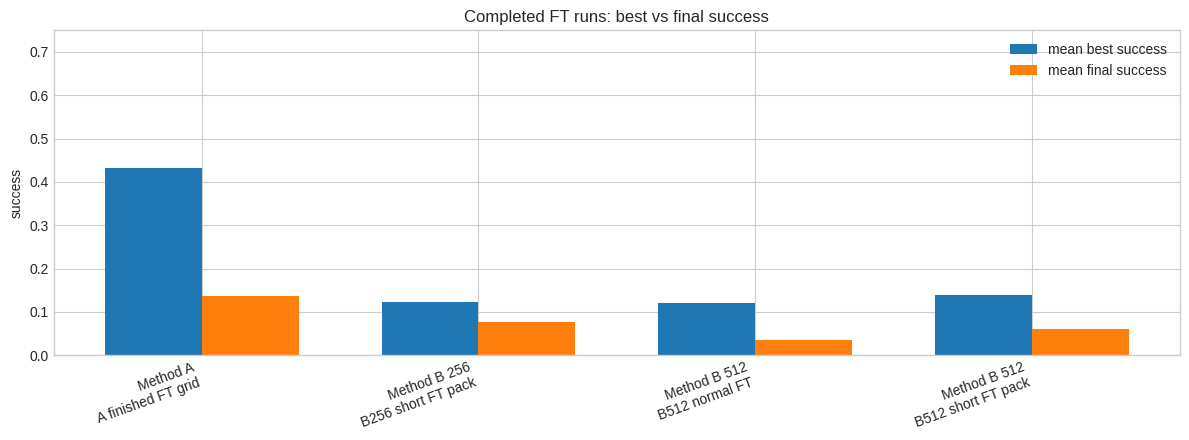

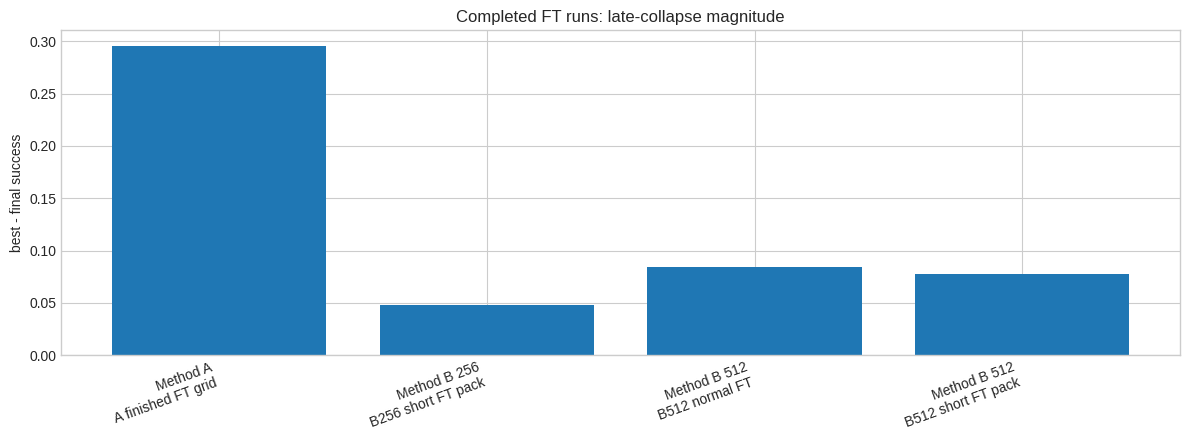

In [9]:
if not complete_summary.empty:
    agg = complete_summary.groupby(['method','source'], dropna=False).agg(
        mean_best=('best_success','mean'),
        mean_final=('final_success','mean'),
        mean_collapse=('collapse','mean'),
    ).reset_index()
    x = np.arange(len(agg))
    width = 0.35
    labels = (agg['method'] + '\n' + agg['source']).tolist()
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.bar(x - width/2, agg['mean_best'], width, label='mean best success')
    ax.bar(x + width/2, agg['mean_final'], width, label='mean final success')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_ylim(0, max(0.75, float(agg[['mean_best','mean_final']].max().max()) + 0.1))
    ax.set_ylabel('success')
    ax.set_title('Completed FT runs: best vs final success')
    ax.legend()
    fig.tight_layout()
    path = ARTIFACT_DIR / 'best_vs_final_success.png'
    fig.savefig(path, dpi=160)
    print('wrote', path)

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.bar(x, agg['mean_collapse'])
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_ylabel('best - final success')
    ax.set_title('Completed FT runs: late-collapse magnitude')
    fig.tight_layout()
    path = ARTIFACT_DIR / 'collapse_by_method.png'
    fig.savefig(path, dpi=160)
    print('wrote', path)
else:
    print('No complete runs for best/final plots.')

wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/return_length_reward_curves.png


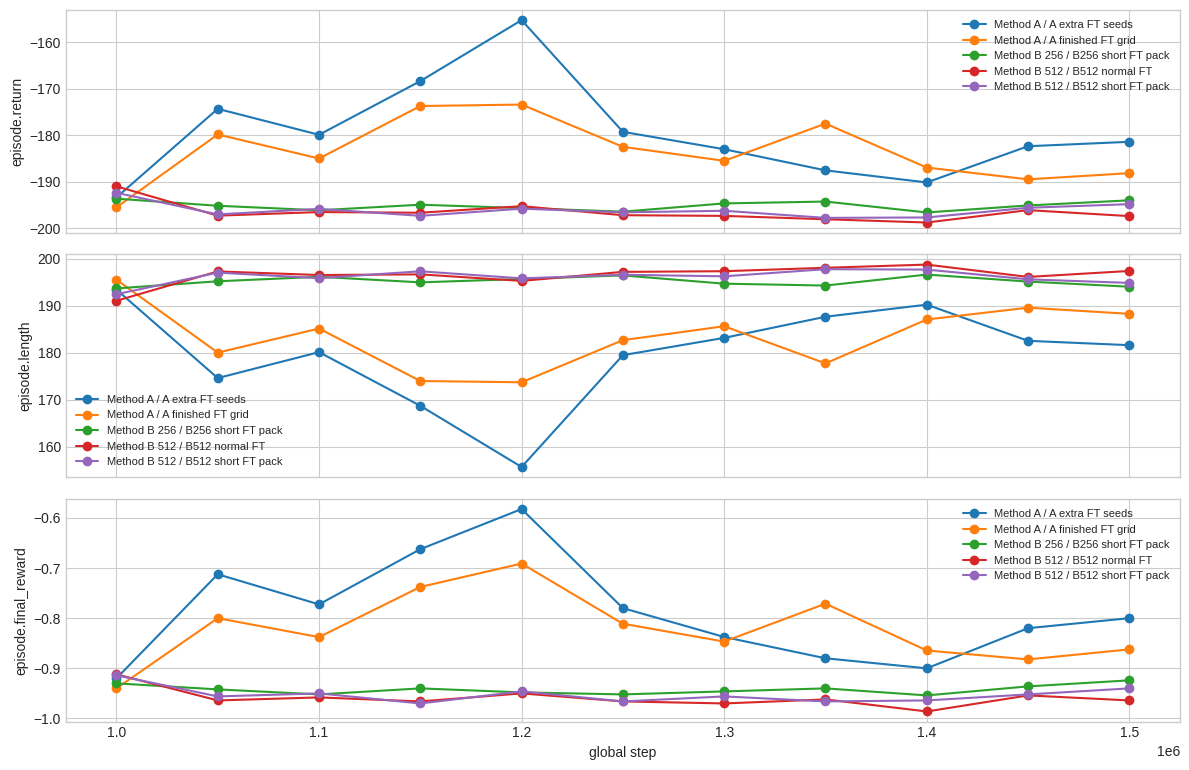

In [10]:
if not eval_df.empty and SUCCESS and RETURN:
    eval_plot_df = eval_df[eval_df['source'].isin(['A finished FT grid','A extra FT seeds','B256 short FT pack','B512 normal FT','B512 short FT pack'])].copy()
    metrics = [RETURN, 'evaluation/episode.length', 'evaluation/episode.final_reward']
    available = [m for m in metrics if m in eval_plot_df.columns]
    fig, axes = plt.subplots(len(available), 1, figsize=(12, max(3, 2.6 * len(available))), sharex=True)
    if len(available) == 1:
        axes = [axes]
    for ax, col in zip(axes, available):
        for (method, source), g in eval_plot_df.groupby(['method','source']):
            grouped = g.groupby('step')[col].apply(finite_mean).reset_index().sort_values('step')
            ax.plot(grouped['step'], grouped[col], marker='o', label=f'{method} / {source}')
        ax.set_ylabel(col.replace('evaluation/',''))
        ax.legend(fontsize=8)
    axes[-1].set_xlabel('global step')
    fig.tight_layout()
    path = ARTIFACT_DIR / 'return_length_reward_curves.png'
    fig.savefig(path, dpi=160)
    print('wrote', path)
else:
    print('Need eval success and return columns for behavior-quality plots.')


## Pretraining And Alignment Metrics

For Method B, healthy InfoNCE pretraining means retrieval accuracy rises and RGB/state action disagreement stays low. These metrics are useful diagnostics, but current FT results show that good alignment alone is not enough to guarantee control transfer.

wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/method_b_pretrain_alignment.png


,method,source,step,training/infonce/current_loss,training/infonce/current_retrieval_acc_rgb_to_state,training/infonce/current_retrieval_acc_state_to_rgb,training/infonce/current_positive_similarity,training/infonce/current_negative_similarity_mean,training/actor_modality/action_mse_rgb_state,training/actor_modality/action_cos_rgb_state,time/epoch_time
199,Method B 256,B256 pretrain,1000000,0.042235,1.0,1.0,0.978179,0.001001,0.006013,0.962068,0.020939
404,Method B 512,B512 pretrain,1000000,0.043494,1.0,1.0,0.981425,-0.000394,0.005782,0.960412,0.020402


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/pretrain_tail_metrics.csv


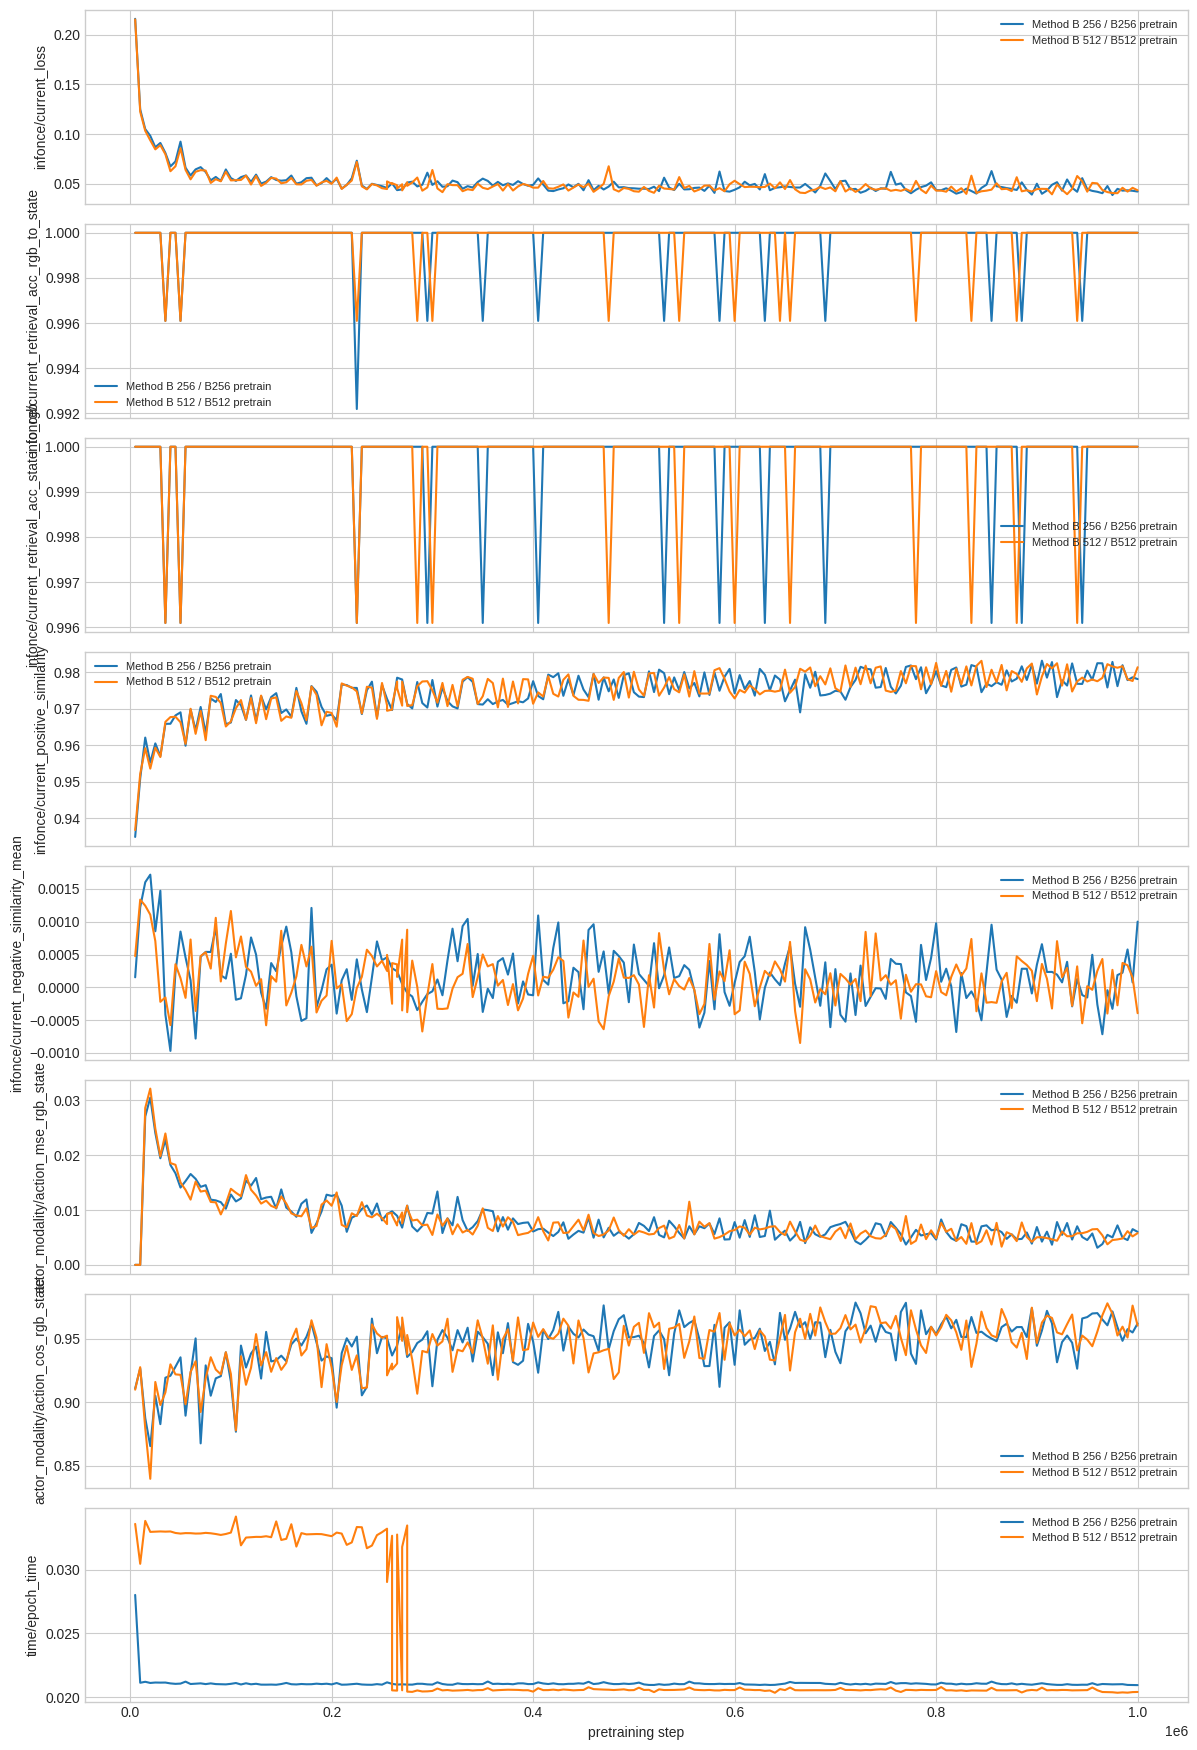

In [11]:
if not pre_df.empty:
    pre_cols = [
        'training/infonce/current_loss',
        'training/infonce/current_retrieval_acc_rgb_to_state',
        'training/infonce/current_retrieval_acc_state_to_rgb',
        'training/infonce/current_positive_similarity',
        'training/infonce/current_negative_similarity_mean',
        'training/actor_modality/action_mse_rgb_state',
        'training/actor_modality/action_cos_rgb_state',
        'time/epoch_time',
    ]
    available = [c for c in pre_cols if c in pre_df.columns]
    fig, axes = plt.subplots(len(available), 1, figsize=(12, max(3, 2.2 * len(available))), sharex=True)
    if len(available) == 1:
        axes = [axes]
    for ax, col in zip(axes, available):
        for label, g in pre_df.groupby(['method', 'source']):
            g = g.sort_values('step')
            ax.plot(g['step'], pd.to_numeric(g[col], errors='coerce'), label=' / '.join(label))
        ax.set_ylabel(col.replace('training/', ''))
        ax.legend(fontsize=8)
    axes[-1].set_xlabel('pretraining step')
    fig.tight_layout()
    fig_path = ARTIFACT_DIR / 'method_b_pretrain_alignment.png'
    fig.savefig(fig_path, dpi=160)
    print('wrote', fig_path)
    tail_cols = ['method','source','step'] + available
    pretrain_tail = pre_df.groupby(['method','source']).tail(1)[tail_cols]
    pretrain_tail_path = ARTIFACT_DIR / 'pretrain_tail_metrics.csv'
    pretrain_tail.to_csv(pretrain_tail_path, index=False)
    display(pretrain_tail)
    print('wrote', pretrain_tail_path)
else:
    print('No Method B pretraining rows found.')

## Fine-Tuning Training Metrics

Important FT diagnostics are actor behavior cloning (`bc_loss`, `mse`, `std`), critic/reward fit (`critic_loss`, `reward_loss`, `pred_true_corr`), InFOM flow losses (`flow_matching_loss`, `neg_elbo_loss`, `kl_loss`), gradient stability, train-validation gaps, and cross-modal action disagreement where present. These are diagnostic, not headline metrics; they help explain why success rises, collapses, or never improves.

In [12]:
if not train_df.empty:
    important_train_metrics = [
        'training/actor/actor_loss',
        'training/actor/bc_loss',
        'training/actor/mse',
        'training/actor/std',
        'training/actor/q_loss',
        'training/actor/q_mean',
        'training/critic/critic_loss',
        'training/reward/reward_loss',
        'training/reward/pred_true_corr',
        'training/reward/pred_reward_mean',
        'training/reward/true_reward_mean',
        'training/flow_occupancy/flow_matching_loss',
        'training/flow_occupancy/current_flow_matching_loss',
        'training/flow_occupancy/future_flow_matching_loss',
        'training/flow_occupancy/neg_elbo_loss',
        'training/flow_occupancy/kl_loss',
        'training/grad/norm',
        'training/actor_modality/action_mse_rgb_state',
        'validation/actor/bc_loss',
        'validation/critic/critic_loss',
        'validation/reward/pred_true_corr',
        'validation/loss/total_loss',
        'time/epoch_time',
    ]
    available_train_metrics = [c for c in important_train_metrics if c in train_df.columns]
    tail = train_df.sort_values('step').groupby(['method','source','run','task','seed'], dropna=False).tail(1)
    tail_cols = ['method','source','run','task','seed','step'] + available_train_metrics
    train_tail = tail[tail_cols].sort_values(['method','source','task','seed','run'])
    train_tail_path = ARTIFACT_DIR / 'ft_train_tail_metrics.csv'
    train_tail.to_csv(train_tail_path, index=False)
    display(train_tail.head(40))
    print('wrote', train_tail_path)
else:
    available_train_metrics = []
    train_tail = pd.DataFrame()
    print('No fine-tuning train rows found.')

,method,source,run,task,seed,step,training/actor/actor_loss,training/actor/bc_loss,training/actor/mse,training/actor/std,training/actor/q_loss,training/actor/q_mean,training/critic/critic_loss,training/reward/reward_loss,training/reward/pred_true_corr,training/reward/pred_reward_mean,training/reward/true_reward_mean,training/flow_occupancy/flow_matching_loss,training/flow_occupancy/current_flow_matching_loss,training/flow_occupancy/future_flow_matching_loss,training/flow_occupancy/neg_elbo_loss,training/flow_occupancy/kl_loss,training/grad/norm,training/actor_modality/action_mse_rgb_state,validation/actor/bc_loss,validation/critic/critic_loss,validation/reward/pred_true_corr,validation/loss/total_loss,time/epoch_time
4999,Method A,A extra FT seeds,task1_seed2_1000kpre_500kft_from_method_a_1m_e...,1,2,1500000,229.029770,139.48715,0.021952,1.0,89.542620,-89.542620,3.614312,5.194951e-05,0.999739,-0.954386,-0.953125,0.007369,0.598506,1.397969e-03,0.007951,1.164861e-02,35.253788,0.048039,139.66862,3.486641,0.999479,233.609150,0.005109
5499,Method A,A extra FT seeds,task1_seed3_1000kpre_500kft_from_method_a_1m_e...,1,3,1500000,48.529633,156.08240,0.243222,1.0,-107.552765,107.552765,3.970786,1.751112e-05,0.999847,-0.987803,-0.984375,0.007460,0.583080,1.645629e-03,0.008045,1.169760e-02,585.099500,0.040294,163.81552,4.111797,0.999843,-65.289490,0.005019
5999,Method A,A extra FT seeds,task1_seed4_1000kpre_500kft_from_method_a_1m_e...,1,4,1500000,-3.842728,161.27473,0.312453,1.0,-165.117460,165.117460,4.266670,4.955786e-05,0.999298,-0.964435,-0.964844,0.007430,0.581445,1.631931e-03,0.008004,1.146990e-02,815.986300,0.092229,163.49640,4.912614,0.999938,-119.450850,0.005106
6499,Method A,A extra FT seeds,task1_seed5_1000kpre_500kft_from_method_a_1m_e...,1,5,1500000,232.174620,139.75203,0.025483,1.0,92.422590,-92.422590,2.696675,6.671863e-06,0.999875,-0.990037,-0.988281,0.006774,0.549749,1.289209e-03,0.007348,1.149347e-02,24.892223,0.162568,139.78831,2.793182,0.999019,234.469560,0.005051
6999,Method A,A extra FT seeds,task4_seed2_1000kpre_500kft_from_method_a_1m_e...,4,2,1500000,36.151764,159.13205,0.283884,1.0,-122.980286,122.980286,1.810444,3.319507e-06,0.999786,-0.992295,-0.992188,0.007400,0.597104,1.443777e-03,0.007976,1.150620e-02,272.966860,0.068976,159.68726,2.803586,0.999252,93.274790,0.005093
7499,Method A,A extra FT seeds,task4_seed3_1000kpre_500kft_from_method_a_1m_e...,4,3,1500000,-196.398770,167.94580,0.401400,1.0,-364.344570,364.344570,3.301755,5.299619e-05,0.999246,-0.968648,-0.968750,0.007373,0.579623,1.593159e-03,0.007954,1.161483e-02,281.998260,0.064903,168.62949,6.291120,0.999334,-232.171400,0.005076
7999,Method A,A extra FT seeds,task4_seed4_1000kpre_500kft_from_method_a_1m_e...,4,4,1500000,232.126680,139.46075,0.021600,1.0,92.665924,-92.665924,3.131312,1.812330e-05,0.999681,-0.971586,-0.972656,0.007242,0.582793,1.428479e-03,0.007816,1.148089e-02,17.034824,0.062235,139.35419,1.895633,0.999706,234.771880,0.005093
8499,Method A,A extra FT seeds,task4_seed5_1000kpre_500kft_from_method_a_1m_e...,4,5,1500000,31.385468,173.82217,0.479752,1.0,-142.436700,142.436700,2.533613,1.304539e-04,0.998575,-0.961244,-0.960938,0.006979,0.551194,1.481373e-03,0.007540,1.122860e-02,1059.745600,0.107557,172.92355,2.799946,0.994647,98.424250,0.005087
499,Method A,A finished FT grid,task1_seed1_1000kpre_500kft_from_method_a_1m,1,1,1500000,-142.484190,167.34827,0.393433,1.0,-309.832460,309.832460,2.948182,3.080869e-04,0.994468,-0.972213,-0.972656,0.007066,0.559952,1.481799e-03,0.007625,1.117752e-02,411.780580,0.075584,168.83379,3.239587,0.999723,-73.788315,0.005052
999,Method A,A finished FT grid,task2_seed0_1000kpre_500kft_from_method_a_1m,2,0,1500000,10.410309,167.11414,0.390311,1.0,-156.703830,156.703830,2.038875,2.992255e-05,0.999496,-0.972201,-0.972656,0.007419,0.607621,1.356366e-03,0.007989,1.140644e-02,1903.726800,0.099187,171.65326,3.030810,0.999519,-4.939059,0.005130


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_train_tail_metrics.csv


In [13]:
if not train_df.empty and not eval_df.empty and SUCCESS and available_train_metrics:
    aligned = []
    for keys, eg in eval_df.groupby(['method','source','run'], dropna=False):
        tg = train_df[(train_df['method'] == keys[0]) & (train_df['source'] == keys[1]) & (train_df['run'] == keys[2])]
        if tg.empty:
            continue
        eg = eg.sort_values('step')
        tg = tg.sort_values('step')
        merged = pd.merge_asof(eg, tg[['step'] + available_train_metrics], on='step', direction='backward', suffixes=('', '_train'))
        aligned.append(merged)
    aligned_df = pd.concat(aligned, ignore_index=True) if aligned else pd.DataFrame()
    if not aligned_df.empty:
        corr_rows = []
        for col in available_train_metrics:
            x = pd.to_numeric(aligned_df[col], errors='coerce')
            y = pd.to_numeric(aligned_df[SUCCESS], errors='coerce')
            if x.notna().sum() > 5 and y.notna().sum() > 5:
                corr_rows.append({'metric': col, 'corr_with_success_at_eval': x.corr(y), 'n': int(x.notna().sum())})
        corr_df = pd.DataFrame(corr_rows).sort_values('corr_with_success_at_eval')
        corr_path = ARTIFACT_DIR / 'ft_metric_correlations.csv'
        aligned_path = ARTIFACT_DIR / 'ft_eval_aligned_train_metrics.csv'
        corr_df.to_csv(corr_path, index=False)
        aligned_df.to_csv(aligned_path, index=False)
        display(corr_df)
        display(aligned_df[['method','source','run','task','seed','step', SUCCESS] + available_train_metrics].tail(30))
        print('wrote', corr_path)
        print('wrote', aligned_path)
    else:
        print('No train rows aligned to eval rows yet.')
else:
    aligned_df = pd.DataFrame()
    print('Need train rows, eval rows, and success metric for collapse diagnostics.')

/home/nick/miniconda3/envs/marl/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/nick/miniconda3/envs/marl/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,metric,corr_with_success_at_eval,n
19,validation/critic/critic_loss,-0.501722,470
6,training/critic/critic_loss,-0.476053,470
22,time/epoch_time,-0.358523,470
5,training/actor/q_mean,-0.227380,470
12,training/flow_occupancy/current_flow_matching_...,-0.199583,470
18,validation/actor/bc_loss,-0.159987,470
2,training/actor/mse,-0.159243,470
1,training/actor/bc_loss,-0.159243,470
16,training/grad/norm,-0.127207,470
8,training/reward/pred_true_corr,-0.113292,470


,method,source,run,task,seed,step,evaluation/success,training/actor/actor_loss,training/actor/bc_loss,training/actor/mse,training/actor/std,training/actor/q_loss,training/actor/q_mean,training/critic/critic_loss,training/reward/reward_loss,training/reward/pred_true_corr,training/reward/pred_reward_mean,training/reward/true_reward_mean,training/flow_occupancy/flow_matching_loss,training/flow_occupancy/current_flow_matching_loss,training/flow_occupancy/future_flow_matching_loss,training/flow_occupancy/neg_elbo_loss,training/flow_occupancy/kl_loss,training/grad/norm,training/actor_modality/action_mse_rgb_state,validation/actor/bc_loss,validation/critic/critic_loss,validation/reward/pred_true_corr,validation/loss/total_loss,time/epoch_time
487,Method B 512,B512 short FT pack,task4_seed1_1000kpre_500kft_from_b512_1m_short...,4,1,1150000,0.02,218.32584,138.93042,0.014529,1.0,79.395410,-79.395410,13.251955,2.425900e-05,0.999981,-0.975798,-0.980469,0.005139,0.504105,9.942681e-05,0.005244,2.098651e-03,30.019596,0.006533,138.98048,8.206966,0.968205,226.53090,0.006333
488,Method B 512,B512 short FT pack,task4_seed1_1000kpre_500kft_from_b512_1m_short...,4,1,1200000,0.00,217.27727,138.73746,0.011956,1.0,78.539810,-78.539810,10.370184,7.517710e-06,0.999885,-0.985470,-0.984375,0.005773,0.573953,3.409724e-05,0.005941,3.351679e-03,23.236480,0.006559,138.70370,8.499503,0.999995,225.82422,0.006371
489,Method B 512,B512 short FT pack,task4_seed1_1000kpre_500kft_from_b512_1m_short...,4,1,1250000,0.00,218.30997,138.62842,0.010502,1.0,79.681550,-79.681550,9.700079,1.321804e-05,0.999739,-0.980540,-0.980469,0.005309,0.521704,9.255894e-05,0.005454,2.912965e-03,17.224926,0.005278,138.61487,9.819762,0.998680,228.22377,0.006327
490,Method B 512,B512 short FT pack,task4_seed1_1000kpre_500kft_from_b512_1m_short...,4,1,1300000,0.00,217.52994,138.66550,0.010996,1.0,78.864440,-78.864440,15.422350,6.556312e-06,0.999929,-0.952975,-0.953125,0.005333,0.528705,4.681607e-05,0.005625,5.829720e-03,54.024315,0.006156,138.83234,10.889608,0.999933,228.42957,0.006359
491,Method B 512,B512 short FT pack,task4_seed1_1000kpre_500kft_from_b512_1m_short...,4,1,1350000,0.00,219.52881,138.52667,0.009145,1.0,81.002140,-81.002140,11.589807,4.407785e-06,0.999980,-0.975966,-0.976562,0.005413,0.532843,8.562995e-05,0.005513,1.999449e-03,27.822716,0.005754,138.72455,8.577763,0.999963,228.20563,0.006307
492,Method B 512,B512 short FT pack,task4_seed1_1000kpre_500kft_from_b512_1m_short...,4,1,1400000,0.04,219.01352,138.62778,0.010493,1.0,80.385740,-80.385740,9.965748,8.221714e-06,0.999967,-0.963315,-0.960938,0.005208,0.512181,8.671322e-05,0.005314,2.129444e-03,28.272602,0.006604,138.74576,10.447927,0.999969,229.77121,0.006350
493,Method B 512,B512 short FT pack,task4_seed1_1000kpre_500kft_from_b512_1m_short...,4,1,1450000,0.04,215.39484,138.69432,0.011381,1.0,76.700510,-76.700510,10.974163,2.081447e-05,0.999482,-0.984861,-0.984375,0.006671,0.644609,2.272961e-04,0.006724,1.050975e-03,29.385803,0.007574,138.61354,12.437353,0.999980,227.89552,0.006320
494,Method B 512,B512 short FT pack,task4_seed1_1000kpre_500kft_from_b512_1m_short...,4,1,1500000,0.00,217.53783,138.68860,0.011304,1.0,78.849230,-78.849230,13.637909,8.491526e-07,0.999993,-0.980663,-0.980469,0.007420,0.739518,2.534100e-05,0.007449,5.798965e-04,21.412895,0.007161,138.53268,12.358591,0.999996,229.72574,0.006339
495,Method B 512,B512 short FT pack,task5_seed0_1000kpre_500kft_from_b512_1m_short...,5,0,1000001,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
496,Method B 512,B512 short FT pack,task5_seed0_1000kpre_500kft_from_b512_1m_short...,5,0,1050000,0.00,219.77007,139.13951,0.017316,1.0,80.630554,-80.630554,9.442739,8.810253e-05,0.998743,-0.965654,-0.968750,0.005532,0.552044,1.144136e-05,0.005701,3.390744e-03,12.200047,0.009581,138.99564,13.024113,0.999439,232.31143,0.006228


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_metric_correlations.csv
wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_eval_aligned_train_metrics.csv


## Best-Vs-Final Diagnostic Deltas

These tables align FT training metrics to each eval point and compare the row nearest the best checkpoint against the row nearest the final checkpoint. They are correlational diagnostics, not causal proof.


In [14]:
if 'aligned_df' in globals() and not aligned_df.empty and not summary.empty and available_train_metrics:
    diagnostic_metrics = [
        'training/actor/bc_loss',
        'training/actor/mse',
        'training/actor/q_mean',
        'training/critic/critic_loss',
        'training/reward/reward_loss',
        'training/reward/pred_true_corr',
        'training/flow_occupancy/flow_matching_loss',
        'training/flow_occupancy/neg_elbo_loss',
        'training/flow_occupancy/kl_loss',
        'training/grad/norm',
        'training/actor_modality/action_mse_rgb_state',
        'validation/actor/bc_loss',
        'validation/critic/critic_loss',
        'validation/reward/pred_true_corr',
        'validation/loss/total_loss',
        'time/epoch_time',
    ]
    diagnostic_metrics = [m for m in diagnostic_metrics if m in aligned_df.columns]
    rows = []
    for _, srow in summary[summary['source'].isin(PRIMARY_SOURCES)].iterrows():
        g = aligned_df[(aligned_df['method'] == srow['method']) & (aligned_df['source'] == srow['source']) & (aligned_df['run'] == srow['run'])]
        if g.empty or pd.isna(srow.get('best_step')) or pd.isna(srow.get('final_step')):
            continue
        for label, target_step in [('best', int(srow['best_step'])), ('final', int(srow['final_step']))]:
            nearest_idx = (pd.to_numeric(g['step'], errors='coerce') - target_step).abs().idxmin()
            rec = {
                'method': srow['method'],
                'source': srow['source'],
                'run': srow['run'],
                'task': srow['task'],
                'seed': srow['seed'],
                'window': label,
                'target_eval_step': target_step,
                'aligned_step': int(g.loc[nearest_idx, 'step']),
                'eval_success': float(g.loc[nearest_idx, SUCCESS]) if SUCCESS in g.columns and pd.notna(g.loc[nearest_idx, SUCCESS]) else np.nan,
            }
            for metric in diagnostic_metrics:
                rec[metric] = pd.to_numeric(pd.Series([g.loc[nearest_idx, metric]]), errors='coerce').iloc[0]
            rows.append(rec)
    best_final_diag_df = pd.DataFrame(rows).sort_values(['method','source','task','seed','run','window']) if rows else pd.DataFrame()
    delta_rows = []
    if not best_final_diag_df.empty:
        for keys, g in best_final_diag_df.groupby(['method','source','run','task','seed'], dropna=False):
            if set(g['window']) >= {'best', 'final'}:
                best = g[g['window'] == 'best'].iloc[0]
                final = g[g['window'] == 'final'].iloc[0]
                rec = {'method': keys[0], 'source': keys[1], 'run': keys[2], 'task': keys[3], 'seed': keys[4]}
                rec['success_delta_final_minus_best'] = final['eval_success'] - best['eval_success']
                for metric in diagnostic_metrics:
                    rec[f'{metric}__final_minus_best'] = final[metric] - best[metric]
                delta_rows.append(rec)
    best_final_delta_df = pd.DataFrame(delta_rows).sort_values(['method','source','task','seed','run']) if delta_rows else pd.DataFrame()
else:
    best_final_diag_df = pd.DataFrame()
    best_final_delta_df = pd.DataFrame()

diag_path = ARTIFACT_DIR / 'ft_best_final_diagnostics.csv'
delta_path = ARTIFACT_DIR / 'ft_best_final_diagnostic_deltas.csv'
best_final_diag_df.to_csv(diag_path, index=False)
best_final_delta_df.to_csv(delta_path, index=False)
display(best_final_diag_df.head(80) if not best_final_diag_df.empty else pd.DataFrame({'status':['no aligned best/final diagnostics']}))
display(best_final_delta_df.head(80) if not best_final_delta_df.empty else pd.DataFrame({'status':['no best/final deltas']}))
print('wrote', diag_path)
print('wrote', delta_path)


,method,source,run,task,seed,window,target_eval_step,aligned_step,eval_success,training/actor/bc_loss,training/actor/mse,training/actor/q_mean,training/critic/critic_loss,training/reward/reward_loss,training/reward/pred_true_corr,training/flow_occupancy/flow_matching_loss,training/flow_occupancy/neg_elbo_loss,training/flow_occupancy/kl_loss,training/grad/norm,training/actor_modality/action_mse_rgb_state,validation/actor/bc_loss,validation/critic/critic_loss,validation/reward/pred_true_corr,validation/loss/total_loss,time/epoch_time
0,Method A,A extra FT seeds,task1_seed2_1000kpre_500kft_from_method_a_1m_e...,1,2,best,1050000,1050000,0.74,139.98592,0.028602,-92.553250,2.672939,6.240202e-04,0.984475,0.007633,0.008024,7.828663e-03,35.876705,0.013847,139.74727,3.347832,0.991501,235.834430,0.005065
1,Method A,A extra FT seeds,task1_seed2_1000kpre_500kft_from_method_a_1m_e...,1,2,final,1500000,1500000,0.44,139.48715,0.021952,-89.542620,3.614312,5.194951e-05,0.999739,0.007369,0.007951,1.164861e-02,35.253788,0.048039,139.66862,3.486641,0.999479,233.609150,0.005109
2,Method A,A extra FT seeds,task1_seed3_1000kpre_500kft_from_method_a_1m_e...,1,3,best,1150000,1150000,0.44,140.04295,0.029362,-92.515960,2.965719,1.355525e-05,0.000000,0.007600,0.008015,8.297274e-03,34.736195,0.013335,139.94360,3.666374,0.996111,235.311610,0.005043
3,Method A,A extra FT seeds,task1_seed3_1000kpre_500kft_from_method_a_1m_e...,1,3,final,1500000,1500000,0.00,156.08240,0.243222,107.552765,3.970786,1.751112e-05,0.999847,0.007460,0.008045,1.169760e-02,585.099500,0.040294,163.81552,4.111797,0.999843,-65.289490,0.005019
4,Method A,A extra FT seeds,task1_seed4_1000kpre_500kft_from_method_a_1m_e...,1,4,best,1050000,1050000,0.68,139.63913,0.023978,-91.834170,3.399637,3.650347e-04,0.990543,0.008178,0.008601,8.460220e-03,30.928028,0.011353,139.90900,3.650212,0.985546,235.541960,0.005132
5,Method A,A extra FT seeds,task1_seed4_1000kpre_500kft_from_method_a_1m_e...,1,4,final,1500000,1500000,0.00,161.27473,0.312453,165.117460,4.266670,4.955786e-05,0.999298,0.007430,0.008004,1.146990e-02,815.986300,0.092229,163.49640,4.912614,0.999938,-119.450850,0.005106
6,Method A,A extra FT seeds,task1_seed5_1000kpre_500kft_from_method_a_1m_e...,1,5,best,1450000,1450000,0.80,139.75339,0.025501,-92.062070,3.905734,1.181293e-03,0.980249,0.007230,0.007786,1.112658e-02,26.449345,0.032818,139.54854,4.659869,0.969083,235.512560,0.005042
7,Method A,A extra FT seeds,task1_seed5_1000kpre_500kft_from_method_a_1m_e...,1,5,final,1500000,1500000,0.74,139.75203,0.025483,-92.422590,2.696675,6.671863e-06,0.999875,0.006774,0.007348,1.149347e-02,24.892223,0.162568,139.78831,2.793182,0.999019,234.469560,0.005051
8,Method A,A extra FT seeds,task4_seed2_1000kpre_500kft_from_method_a_1m_e...,4,2,best,1200000,1200000,0.64,139.97348,0.028436,-93.718590,2.407775,1.830554e-04,0.995454,0.007002,0.007388,7.712118e-03,22.765877,0.014260,139.63255,2.814027,0.995993,235.688420,0.005134
9,Method A,A extra FT seeds,task4_seed2_1000kpre_500kft_from_method_a_1m_e...,4,2,final,1500000,1500000,0.00,159.13205,0.283884,122.980286,1.810444,3.319507e-06,0.999786,0.007400,0.007976,1.150620e-02,272.966860,0.068976,159.68726,2.803586,0.999252,93.274790,0.005093


,method,source,run,task,seed,success_delta_final_minus_best,training/actor/bc_loss__final_minus_best,training/actor/mse__final_minus_best,training/actor/q_mean__final_minus_best,training/critic/critic_loss__final_minus_best,training/reward/reward_loss__final_minus_best,training/reward/pred_true_corr__final_minus_best,training/flow_occupancy/flow_matching_loss__final_minus_best,training/flow_occupancy/neg_elbo_loss__final_minus_best,training/flow_occupancy/kl_loss__final_minus_best,training/grad/norm__final_minus_best,training/actor_modality/action_mse_rgb_state__final_minus_best,validation/actor/bc_loss__final_minus_best,validation/critic/critic_loss__final_minus_best,validation/reward/pred_true_corr__final_minus_best,validation/loss/total_loss__final_minus_best,time/epoch_time__final_minus_best
0,Method A,A extra FT seeds,task1_seed2_1000kpre_500kft_from_method_a_1m_e...,1,2,-0.30,-0.49877,-0.006650,3.010630,0.941373,-5.720707e-04,0.015264,-0.000264,-0.000073,3.819944e-03,-0.622917,0.034192,-0.07865,0.138809,0.007979,-2.225280,4.339242e-05
1,Method A,A extra FT seeds,task1_seed3_1000kpre_500kft_from_method_a_1m_e...,1,3,-0.44,16.03945,0.213859,200.068725,1.005067,3.955868e-06,0.999847,-0.000140,0.000030,3.400324e-03,550.363305,0.026959,23.87192,0.445423,0.003733,-300.601100,-2.420783e-05
2,Method A,A extra FT seeds,task1_seed4_1000kpre_500kft_from_method_a_1m_e...,1,4,-0.68,21.63560,0.288475,256.951630,0.867033,-3.154768e-04,0.008756,-0.000748,-0.000598,3.009677e-03,785.058272,0.080876,23.58740,1.262402,0.014392,-354.992810,-2.612758e-05
3,Method A,A extra FT seeds,task1_seed5_1000kpre_500kft_from_method_a_1m_e...,1,5,-0.06,-0.00136,-0.000018,-0.360520,-1.209059,-1.174621e-03,0.019627,-0.000456,-0.000438,3.668840e-04,-1.557122,0.129749,0.23977,-1.866687,0.029936,-1.043000,9.192228e-06
4,Method A,A extra FT seeds,task4_seed2_1000kpre_500kft_from_method_a_1m_e...,4,2,-0.64,19.15857,0.255448,216.698876,-0.597331,-1.797358e-04,0.004333,0.000398,0.000588,3.794082e-03,250.200983,0.054717,20.05471,-0.010442,0.003259,-142.413630,-4.063678e-05
5,Method A,A extra FT seeds,task4_seed3_1000kpre_500kft_from_method_a_1m_e...,4,3,-0.24,27.89910,0.371988,457.187820,1.166010,-1.265397e-04,0.002145,-0.000297,-0.000131,3.327091e-03,255.563282,0.036512,28.65897,4.296090,0.020990,-467.108240,1.228833e-05
6,Method A,A extra FT seeds,task4_seed4_1000kpre_500kft_from_method_a_1m_e...,4,4,-0.04,-0.23313,-0.003108,0.097186,-0.090600,-5.989795e-03,0.102236,0.000329,0.000429,1.999407e-03,-20.098923,0.037977,-0.26120,-0.919225,0.000401,0.118330,-5.943441e-05
7,Method A,A extra FT seeds,task4_seed5_1000kpre_500kft_from_method_a_1m_e...,4,5,-0.26,34.32540,0.457672,235.843866,-0.259613,-6.803789e-04,0.015661,-0.000614,-0.000470,2.873110e-03,1039.161188,0.098458,33.02157,0.444541,0.012908,-135.559870,2.535939e-05
8,Method A,A finished FT grid,task1_seed1_1000kpre_500kft_from_method_a_1m,1,1,-0.62,27.76136,0.370152,401.043900,0.090423,2.688685e-04,-0.004645,-0.000474,-0.000338,2.725700e-03,361.675767,0.065475,29.12959,0.517698,0.004164,-308.089085,-4.446411e-05
9,Method A,A finished FT grid,task2_seed0_1000kpre_500kft_from_method_a_1m,2,0,-0.24,25.61136,0.341485,245.640994,-1.435535,-6.399054e-03,0.093976,0.000283,0.000450,3.327440e-03,1848.665124,0.080328,30.56343,-0.202883,0.028941,-240.102909,-3.849959e-05


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_best_final_diagnostics.csv
wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_best_final_diagnostic_deltas.csv


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_actor_losses_curves.png


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_critic_reward_curves.png


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_flow_grad_runtime_curves.png


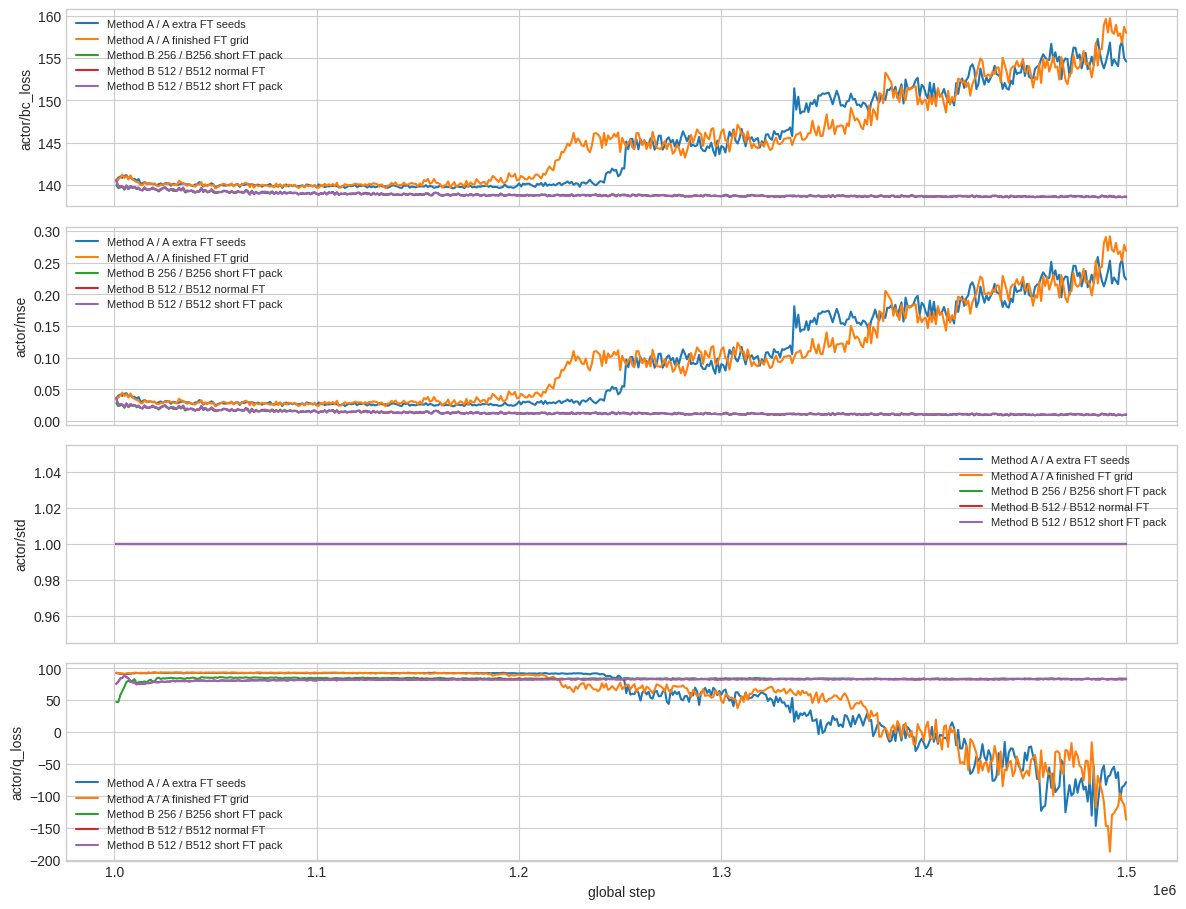

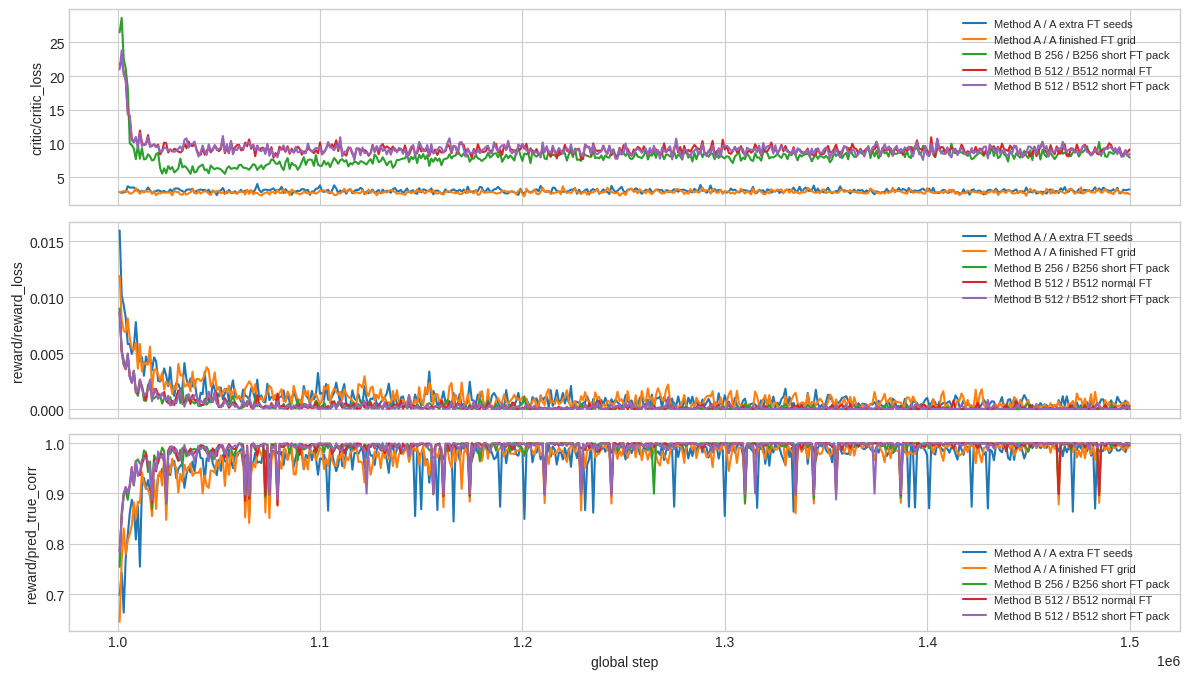

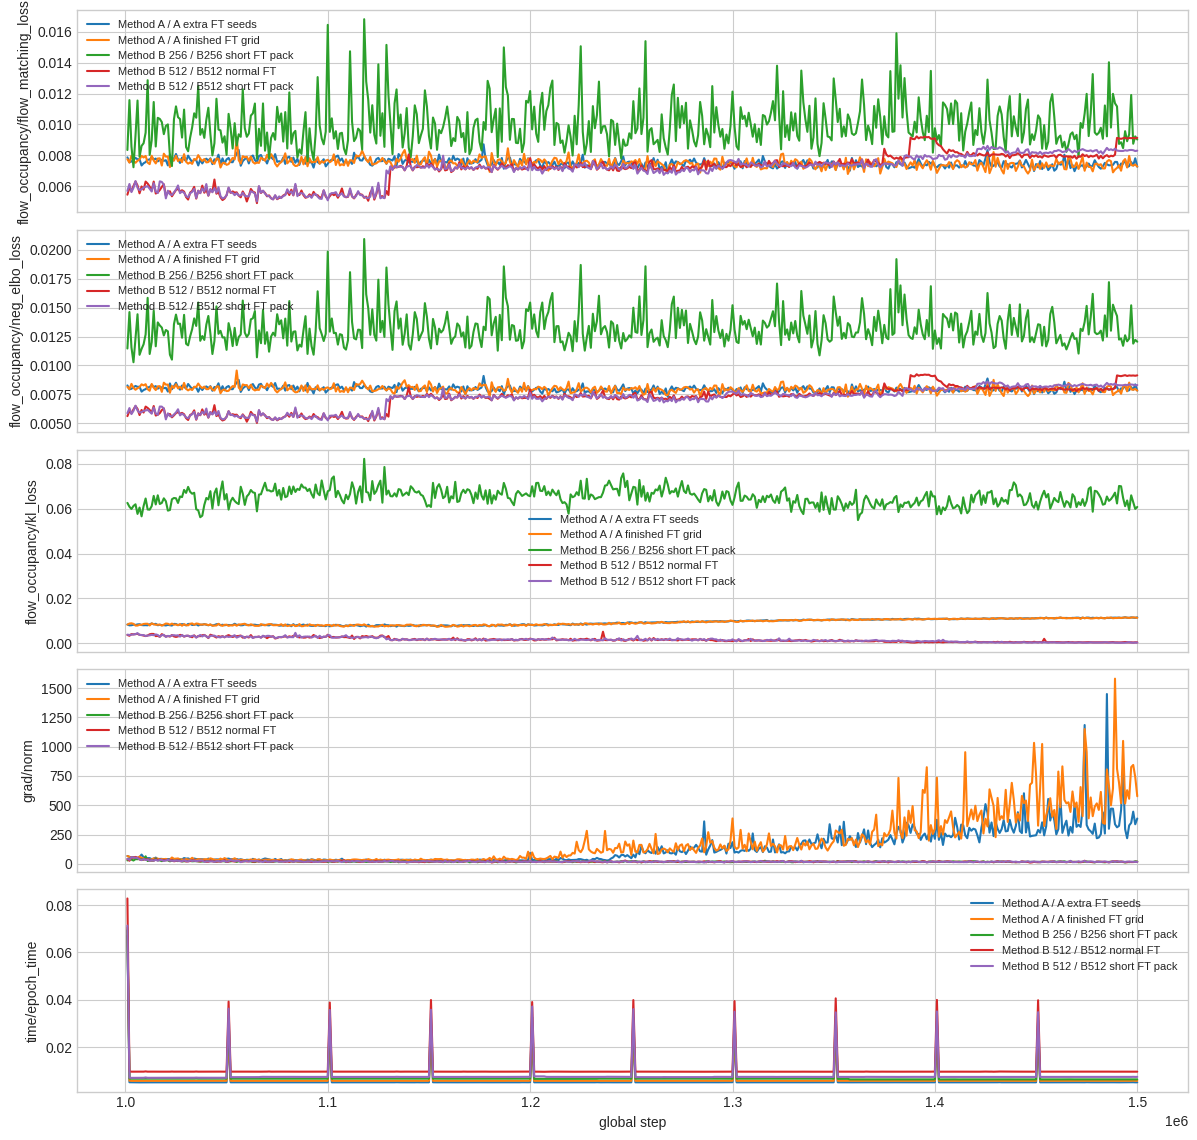

In [15]:
if not train_df.empty and available_train_metrics:
    metric_groups = {
        'actor_losses': ['training/actor/bc_loss','training/actor/mse','training/actor/std','training/actor/q_loss'],
        'critic_reward': ['training/critic/critic_loss','training/reward/reward_loss','training/reward/pred_true_corr'],
        'flow_grad_runtime': ['training/flow_occupancy/flow_matching_loss','training/flow_occupancy/neg_elbo_loss','training/flow_occupancy/kl_loss','training/grad/norm','time/epoch_time'],
    }
    for group_name, cols in metric_groups.items():
        cols = [c for c in cols if c in train_df.columns]
        if not cols:
            continue
        fig, axes = plt.subplots(len(cols), 1, figsize=(12, max(3, 2.3 * len(cols))), sharex=True)
        if len(cols) == 1:
            axes = [axes]
        dfp = train_df[train_df['source'].isin(['A finished FT grid','A extra FT seeds','B256 short FT pack','B512 normal FT','B512 short FT pack'])].copy()
        for ax, col in zip(axes, cols):
            for (method, source), g in dfp.groupby(['method','source']):
                grouped = g.groupby('step')[col].apply(finite_mean).reset_index().sort_values('step')
                ax.plot(grouped['step'], grouped[col], label=f'{method} / {source}')
            ax.set_ylabel(col.replace('training/',''))
            ax.legend(fontsize=8)
        axes[-1].set_xlabel('global step')
        fig.tight_layout()
        path = ARTIFACT_DIR / f'ft_{group_name}_curves.png'
        fig.savefig(path, dpi=160)
        print('wrote', path)
else:
    print('No training metric plots generated.')


## Logs, Checkpoints, And Runtime

The copied log index links local artifacts to Unity Slurm logs. Use it to inspect restore source, JAX/CUDA probe, device-cache size, checkpoint saves, signal/requeue events, and warnings/errors without embedding giant raw logs directly in the notebook.

In [16]:
def safe_local_log_name(remote_path: str) -> str:
    # Include the run root stem when possible to avoid collisions across campaigns.
    parts = Path(remote_path).parts
    stem = 'unknown'
    for part in parts:
        if part.startswith('cross_modal_') or part.startswith('state_distilled_'):
            stem = part
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', f'{stem}__{Path(remote_path).name}')

log_rows = []
if not log_manifest_df.empty:
    for row in log_manifest_df.to_dict('records'):
        remote = row['remote_log_path']
        local = LOG_DIR / safe_local_log_name(remote)
        try:
            run_local(['scp', '-q', f'{HOST}:{remote}', str(local)], timeout=120)
            copied = True
            error = ''
            size = local.stat().st_size if local.exists() else np.nan
        except Exception as exc:
            copied = False
            error = repr(exc)
            size = np.nan
        out = dict(row)
        out.update({
            'local_log_path': str(local.relative_to(REPO_ROOT)) if local.exists() else '',
            'copied': copied,
            'copy_error': error,
            'local_size': size,
        })
        log_rows.append(out)
logs_index_df = pd.DataFrame(log_rows)
logs_index_path = ARTIFACT_DIR / 'logs_index.csv'
logs_index_df.to_csv(logs_index_path, index=False)
display(logs_index_df[['method','source','remote_log_name','remote_log_size','copied','local_log_path']].head(80) if not logs_index_df.empty else pd.DataFrame({'status':['no logs found']}))
print('wrote', logs_index_path)

,method,source,remote_log_name,remote_log_size,copied,local_log_path
0,Method A,A finished FT grid,sd-infom-t1-s1-56902006.err,1661159,True,output/jupyter-notebook/artifacts/method-b-ft-...
1,Method A,A finished FT grid,sd-infom-t1-s1-56902006.out,8723,True,output/jupyter-notebook/artifacts/method-b-ft-...
2,Method A,A finished FT grid,sd-infom-t2-s0-56902010.err,1728884,True,output/jupyter-notebook/artifacts/method-b-ft-...
3,Method A,A finished FT grid,sd-infom-t2-s0-56902010.out,9718,True,output/jupyter-notebook/artifacts/method-b-ft-...
4,Method A,A finished FT grid,sd-infom-t2-s1-56902012.err,1728737,True,output/jupyter-notebook/artifacts/method-b-ft-...
5,Method A,A finished FT grid,sd-infom-t2-s1-56902012.out,9223,True,output/jupyter-notebook/artifacts/method-b-ft-...
6,Method A,A finished FT grid,sd-infom-t3-s0-56902015.err,2654512,True,output/jupyter-notebook/artifacts/method-b-ft-...
7,Method A,A finished FT grid,sd-infom-t3-s0-56902015.out,9273,True,output/jupyter-notebook/artifacts/method-b-ft-...
8,Method A,A finished FT grid,sd-infom-t3-s1-56902586.err,1728678,True,output/jupyter-notebook/artifacts/method-b-ft-...
9,Method A,A finished FT grid,sd-infom-t3-s1-56902586.out,10698,True,output/jupyter-notebook/artifacts/method-b-ft-...


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/logs_index.csv


In [17]:
def scan_log_text(path: Path) -> dict:
    text = path.read_text(errors='replace') if path.exists() else ''
    patterns = {
        'restored_pretrain': r'Restored full training checkpoint from .*method_b_diag',
        'restored_local': r'Restored full training checkpoint from .*short.*checkpoints/latest.pkl|Resuming .* using .*checkpoints/latest.pkl',
        'device_cache': r'DeviceBridgeDataset cache ready',
        'saved_full_checkpoint': r'Saved full training checkpoint',
        'requeue': r'Requeueing|checkpoint/preflight|Received signal',
        'jax_ok': r'"ok": true',
        'cuda_error': r'CUDA|XLA|jaxlib|Traceback|Error|FAILED|failed',
        'open_gl_warning': r'OpenGL_accelerate|MUJOCO_GL',
    }
    return {name: len(re.findall(pattern, text, flags=re.IGNORECASE)) for name, pattern in patterns.items()}

if 'logs_index_df' in globals() and not logs_index_df.empty:
    event_rows = []
    for row in logs_index_df.to_dict('records'):
        if not row.get('copied') or not row.get('local_log_path'):
            continue
        local = REPO_ROOT / row['local_log_path']
        events = scan_log_text(local)
        events.update({
            'method': row['method'],
            'source': row['source'],
            'remote_log_name': row['remote_log_name'],
            'local_log_path': row['local_log_path'],
        })
        event_rows.append(events)
    log_events_df = pd.DataFrame(event_rows)
else:
    log_events_df = pd.DataFrame()

log_events_path = ARTIFACT_DIR / 'log_events_summary.csv'
log_events_df.to_csv(log_events_path, index=False)
display(log_events_df.sort_values(['source','remote_log_name']).head(100) if not log_events_df.empty else pd.DataFrame({'status':['no copied logs to scan']}))
print('wrote', log_events_path)

print('Recent Slurm queue/status excerpt:')
print(snapshot.get('slurm_status',''))
print('Recent sacct excerpt:')
print(snapshot.get('recent_sacct',''))

,restored_pretrain,restored_local,device_cache,saved_full_checkpoint,requeue,jax_ok,cuda_error,open_gl_warning,method,source,remote_log_name,local_log_path
37,0,0,0,0,0,0,18,3,Method A,A extra FT seeds,sd-infom-t1-s2-57205872.err,output/jupyter-notebook/artifacts/method-b-ft-...
38,0,1,1,11,0,1,6,0,Method A,A extra FT seeds,sd-infom-t1-s2-57205872.out,output/jupyter-notebook/artifacts/method-b-ft-...
39,0,0,0,0,0,0,18,3,Method A,A extra FT seeds,sd-infom-t1-s3-57205874.err,output/jupyter-notebook/artifacts/method-b-ft-...
40,0,1,1,11,0,1,6,0,Method A,A extra FT seeds,sd-infom-t1-s3-57205874.out,output/jupyter-notebook/artifacts/method-b-ft-...
41,0,0,0,0,0,0,18,3,Method A,A extra FT seeds,sd-infom-t1-s4-57205875.err,output/jupyter-notebook/artifacts/method-b-ft-...
42,0,1,1,11,0,1,6,0,Method A,A extra FT seeds,sd-infom-t1-s4-57205875.out,output/jupyter-notebook/artifacts/method-b-ft-...
43,0,0,0,0,0,0,18,3,Method A,A extra FT seeds,sd-infom-t1-s5-57205876.err,output/jupyter-notebook/artifacts/method-b-ft-...
44,0,1,1,11,0,1,6,0,Method A,A extra FT seeds,sd-infom-t1-s5-57205876.out,output/jupyter-notebook/artifacts/method-b-ft-...
45,0,0,0,0,0,0,18,3,Method A,A extra FT seeds,sd-infom-t4-s2-57205755.err,output/jupyter-notebook/artifacts/method-b-ft-...
46,0,1,1,11,0,1,6,0,Method A,A extra FT seeds,sd-infom-t4-s2-57205755.out,output/jupyter-notebook/artifacts/method-b-ft-...


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/log_events_summary.csv
Recent Slurm queue/status excerpt:
             JOBID PARTITION          QOS                           NAME    STATE         TIME   TIME_LIMIT       NODELIST(REASON) TRES_PER_NOD

Recent sacct excerpt:
JobID|JobName|Partition|QOS|State|ExitCode|Elapsed|Timelimit|AllocTRES|NodeList
56857944|sd-infom-t1-s0|gpu-preempt|normal|COMPLETED|0:0|05:33:34|10:00:00|billing=8,cpu=8,gres/gpu:a100=1,gres/gpu=1,mem=128G,node=1|ece-gpu001
56872490|tcn-infom-t1-s0|gpu|short|COMPLETED|0:0|00:15:59|03:50:00|billing=8,cpu=8,gres/gpu:a100=1,gres/gpu=1,mem=160G,node=1|gpu023
56874321|tcn-infom-t1-s0|gpu-preempt|short|CANCELLED by 5798|0:0|02:31:50|03:50:00|billing=8,cpu=8,gres/gpu:a100=1,gres/gpu=1,mem=160G,node=1|gpu042
56891473|tcn-infom-t1-s0|gpu-preempt|normal|COMPLETED|0:0|05:52:38|10:00:00|billing=8,cpu=8,gres/gpu:a100=1,gres/gpu=1,mem=160G,node=1|ece-gpu001
56891558|sd-infom

In [18]:
runtime_rows = []
if not train_df.empty and 'time/epoch_time' in train_df.columns:
    for keys, g in train_df.groupby(['method','source','run','task','seed'], dropna=False):
        epochs = pd.to_numeric(g['time/epoch_time'], errors='coerce')
        runtime_rows.append({
            'method': keys[0], 'source': keys[1], 'run': keys[2], 'task': keys[3], 'seed': keys[4],
            'train_rows': len(g),
            'median_epoch_time': float(epochs.median()) if epochs.notna().any() else np.nan,
            'mean_epoch_time': float(epochs.mean()) if epochs.notna().any() else np.nan,
            'last_step': int(pd.to_numeric(g['step'], errors='coerce').max()) if 'step' in g else np.nan,
        })
runtime_df = pd.DataFrame(runtime_rows).sort_values(['method','source','task','seed','run']) if runtime_rows else pd.DataFrame()
runtime_path = ARTIFACT_DIR / 'runtime_summary.csv'
runtime_df.to_csv(runtime_path, index=False)
display(runtime_df.head(80) if not runtime_df.empty else pd.DataFrame({'status':['no runtime rows']}))
print('wrote', runtime_path)

,method,source,run,task,seed,train_rows,median_epoch_time,mean_epoch_time,last_step
0,Method A,A extra FT seeds,task1_seed2_1000kpre_500kft_from_method_a_1m_e...,1,2,500,0.005094,0.005537,1500000
1,Method A,A extra FT seeds,task1_seed3_1000kpre_500kft_from_method_a_1m_e...,1,3,500,0.005028,0.005504,1500000
2,Method A,A extra FT seeds,task1_seed4_1000kpre_500kft_from_method_a_1m_e...,1,4,500,0.005120,0.005584,1500000
3,Method A,A extra FT seeds,task1_seed5_1000kpre_500kft_from_method_a_1m_e...,1,5,500,0.005048,0.005497,1500000
4,Method A,A extra FT seeds,task4_seed2_1000kpre_500kft_from_method_a_1m_e...,4,2,500,0.005123,0.005589,1500000
5,Method A,A extra FT seeds,task4_seed3_1000kpre_500kft_from_method_a_1m_e...,4,3,500,0.005062,0.005558,1500000
6,Method A,A extra FT seeds,task4_seed4_1000kpre_500kft_from_method_a_1m_e...,4,4,500,0.005138,0.005612,1500000
7,Method A,A extra FT seeds,task4_seed5_1000kpre_500kft_from_method_a_1m_e...,4,5,500,0.005083,0.005573,1500000
8,Method A,A finished FT grid,task1_seed1_1000kpre_500kft_from_method_a_1m,1,1,500,0.005062,0.005522,1500000
9,Method A,A finished FT grid,task2_seed0_1000kpre_500kft_from_method_a_1m,2,0,500,0.005142,0.005641,1500000


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/runtime_summary.csv


## Claim Readiness

The table below separates what the current evidence supports from what remains insufficient. This is the paper-facing guardrail for interpreting the bridge experiments.


In [19]:
claim_rows = []

def claim(statement, status, evidence, gap):
    claim_rows.append({'claim': statement, 'status': status, 'evidence': evidence, 'gap_or_caveat': gap})

if not paper_by_task.empty:
    a_task4 = paper_by_task[(paper_by_task['method'] == 'Method A') & (paper_by_task['task'] == 4)]
    b_task4 = paper_by_task[(paper_by_task['method'].str.startswith('Method B')) & (paper_by_task['task'] == 4)]
    a_overall = paper_by_method[paper_by_method['method'] == 'Method A'] if not paper_by_method.empty else pd.DataFrame()
    b_overall = paper_by_method[paper_by_method['method'].str.startswith('Method B')] if not paper_by_method.empty else pd.DataFrame()
    claim(
        'Method A is the primary bridge method to scale.',
        'supported',
        f"Method A task4 paper-window/final evidence is strongest; aggregate best/final exceeds B variants in current complete runs. A task4 rows: {a_task4[['source','n_runs','mean_paper_success','mean_final_success','mean_collapse']].to_dict('records') if not a_task4.empty else 'missing'}",
        'Needs more Method A seeds on task4 and one additional high-target task before broader claims.',
    )
    claim(
        'Method B contrastive/TCN alignment is sufficient for control transfer.',
        'not supported',
        f"Method B pretraining retrieval reaches 1.0, but FT paper-window success stays low. B task4 rows: {b_task4[['source','n_runs','mean_paper_success','mean_final_success']].to_dict('records') if not b_task4.empty else 'missing'}",
        'This argues alignment alone is insufficient; do not spend remaining time scaling B unless new B512 completion changes this materially.',
    )
else:
    claim('Paper-style comparisons are available.', 'blocked', 'paper_by_task is empty', 'Refresh snapshot and rerun notebook.')

if not collapse_timing_df.empty:
    method_a_collapse = collapse_timing_df[collapse_timing_df['method'] == 'Method A']['collapse'].mean()
    claim(
        'Late FT collapse is a central limitation.',
        'supported',
        f"Mean Method A best-final collapse in observed runs is {method_a_collapse:.3f}.",
        'Need distinguish instability from dataset/task mismatch; report best checkpoint only as diagnostic, not headline.',
    )

claim(
    'Exact paper replication has been fully established.',
    'not established',
    'Paper-style metric is now computed, but FT dataset provenance and seed count remain caveats.',
    'Do not claim paper-level replication; use original InFOM as contextual baseline only.',
)

claim_df = pd.DataFrame(claim_rows)
claim_path = ARTIFACT_DIR / 'claim_readiness.csv'
claim_df.to_csv(claim_path, index=False)
display(claim_df)
print('wrote', claim_path)


,claim,status,evidence,gap_or_caveat
0,Method A is the primary bridge method to scale.,supported,Method A task4 paper-window/final evidence is ...,Needs more Method A seeds on task4 and one add...
1,Method B contrastive/TCN alignment is sufficie...,not supported,"Method B pretraining retrieval reaches 1.0, bu...",This argues alignment alone is insufficient; d...
2,Late FT collapse is a central limitation.,supported,Mean Method A best-final collapse in observed ...,Need distinguish instability from dataset/task...
3,Exact paper replication has been fully establi...,not established,"Paper-style metric is now computed, but FT dat...",Do not claim paper-level replication; use orig...


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/claim_readiness.csv


## Current Interpretation

Evidence from completed runs should be read using the paper-style metric first. Method A is currently the only bridge method with a meaningful control signal, especially on task4. Method B can align RGB/state latents very well during pretraining, but its FT success remains weak, so contrastive alignment alone is not enough for this InFOM control stack.

The main limitation is late fine-tuning collapse: several Method A runs reach useful best checkpoints but lose performance by the final reporting window. This is why the notebook reports both paper-window success and best/final collapse, and why additional Method A seeds should target task4 plus task1 as a high-paper-target stress test.


## Demo Artifacts

The demo summaries are a behavioral sanity check for Method A best-vs-final checkpoints. They are not a replacement for full eval curves, but they help identify whether a checkpoint is actually solving episodes or just producing a noisy scalar improvement.

In [20]:
demo_rows = []
demo_root = ARTIFACT_DIR / 'demos'
if demo_root.exists():
    for path in sorted(demo_root.glob('*/*_summary.json')):
        with open(path) as f:
            data = json.load(f)
        info = data.get('eval_info', {}) if isinstance(data.get('eval_info', {}), dict) else {}
        demo_rows.append({
            'demo': path.parent.name,
            'episodes': data.get('num_eval_episodes', data.get('eval_episodes')),
            'success_rate': info.get('success', info.get('episode.success', data.get('success_rate'))),
            'mean_return': info.get('episode.return', data.get('mean_return')),
            'mean_length': info.get('episode.length', data.get('mean_length')),
            'summary_path': str(path.relative_to(REPO_ROOT)),
        })
if demo_rows:
    demo_df = pd.DataFrame(demo_rows).sort_values('demo')
    demo_summary_path = ARTIFACT_DIR / 'demo_summary.csv'
    demo_df.to_csv(demo_summary_path, index=False)
    display(demo_df)
    print('wrote', demo_summary_path)
else:
    demo_df = pd.DataFrame()
    print('No local demo summaries found yet. Run scripts/submit_ogbench_checkpoint_demos_unity.py and rsync the demo directory.')

,demo,episodes,success_rate,mean_return,mean_length,summary_path
0,task1_seed1_best,10,0.7,-107.4,108.1,output/jupyter-notebook/artifacts/method-b-ft-...
1,task1_seed1_final,10,0.0,-200.0,200.0,output/jupyter-notebook/artifacts/method-b-ft-...
2,task4_seed1_best,10,0.7,-136.2,136.9,output/jupyter-notebook/artifacts/method-b-ft-...
3,task4_seed1_final,10,0.5,-151.7,152.2,output/jupyter-notebook/artifacts/method-b-ft-...


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/demo_summary.csv


## Validation Checks

In [21]:
checks = []

def add_check(name, passed, detail):
    checks.append({'check': name, 'passed': bool(passed), 'detail': detail})

if 'paper_metric_df' in globals() and not paper_metric_df.empty:
    add_check('Paper-window metrics exist', True, f'{len(paper_metric_df)} run rows with paper-window fields')
    complete_window = paper_metric_df['complete_for_paper_metric'].sum() if 'complete_for_paper_metric' in paper_metric_df else 0
    add_check('Paper-window complete rows exist', complete_window > 0, f'{complete_window} complete paper-window rows')
else:
    add_check('Paper-window metrics exist', False, 'paper_metric_df empty or missing')

if 'coverage_df' in globals() and not coverage_df.empty:
    add_check('Seed coverage table exists', True, f'{len(coverage_df)} coverage rows')
else:
    add_check('Seed coverage table exists', False, 'coverage_df empty or missing')

if not summary.empty:
    b256 = summary[(summary['source'] == 'B256 short FT pack') & summary['is_complete']]
    add_check('B256 complete run count', len(b256) >= 10, f'{len(b256)} complete B256 short-pack runs')
    add_check('Completed runs final step', (complete_summary['final_step'] >= EXPECTED_FINAL_STEP).all() if not complete_summary.empty else False, 'all complete-summary runs reached final step')
    b512_short = summary[summary['source'] == 'B512 short FT pack']
    if not b512_short.empty:
        incomplete = b512_short[b512_short['status'] != 'complete']
        add_check('B512 short-pack partial labeling', True, f'{len(incomplete)} incomplete B512 short-pack rows explicitly labeled')
else:
    add_check('summary exists', False, 'summary table empty')

if 'demo_df' in globals() and not demo_df.empty:
    add_check('Demo success parsed', demo_df['success_rate'].notna().all(), 'demo success rates are non-NaN')
else:
    add_check('Demo success parsed', True, 'no demo summaries available; skipped')

if 'logs_index_df' in globals() and not logs_index_df.empty:
    add_check('Logs copied or indexed', logs_index_df['local_log_path'].astype(str).ne('').any(), f'{logs_index_df["local_log_path"].astype(str).ne("").sum()} copied logs')
else:
    add_check('Logs copied or indexed', False, 'no log index rows')

checks_df = pd.DataFrame(checks)
checks_path = ARTIFACT_DIR / 'validation_checks.csv'
checks_df.to_csv(checks_path, index=False)
display(checks_df)
print('wrote', checks_path)
if not checks_df['passed'].all():
    print('WARNING: one or more validation checks did not pass; inspect details above.')


,check,passed,detail
0,Paper-window metrics exist,True,47 run rows with paper-window fields
1,Paper-window complete rows exist,True,47 complete paper-window rows
2,Seed coverage table exists,True,47 coverage rows
3,B256 complete run count,True,10 complete B256 short-pack runs
4,Completed runs final step,True,all complete-summary runs reached final step
5,B512 short-pack partial labeling,True,0 incomplete B512 short-pack rows explicitly l...
6,Demo success parsed,True,demo success rates are non-NaN
7,Logs copied or indexed,True,137 copied logs


wrote /home/nick/infom-learning-from-obs/output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/validation_checks.csv


## Demo Generation Commands

Local demo rendering is blocked in this environment when `ogbench` is unavailable. Use the script below inside the Unity repo from a Slurm GPU job to regenerate or expand demo targets.

In [22]:
DEMO_COMMANDS = [
    "python scripts/render_ogbench_checkpoint_demo.py --env-name bridge-cube-single-play-singletask-task4-v0 --dataset-dir /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/data/bridge_cube_single_play_20260506_004058 --agent agents/cross_modal_state_distilled_infom.py --checkpoint /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs/state_distilled_method_a_ft_grid_20260507_004541/runs/state_distilled_method_a_ft_grid/task4_seed1_1000kpre_500kft_from_method_a_1m/params_1350000.pkl --out-dir /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs/demos/method_a_task4_seed1_best --seed 1 --eval-episodes 10 --video-episodes 2",
    "python scripts/render_ogbench_checkpoint_demo.py --env-name bridge-cube-single-play-singletask-task4-v0 --dataset-dir /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/data/bridge_cube_single_play_20260506_004058 --agent agents/cross_modal_state_distilled_infom.py --checkpoint /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs/state_distilled_method_a_ft_grid_20260507_004541/runs/state_distilled_method_a_ft_grid/task4_seed1_1000kpre_500kft_from_method_a_1m/checkpoints/latest.pkl --out-dir /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs/demos/method_a_task4_seed1_final --seed 1 --eval-episodes 10 --video-episodes 2",
    "python scripts/render_ogbench_checkpoint_demo.py --env-name bridge-cube-single-play-singletask-task1-v0 --dataset-dir /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/data/bridge_cube_single_play_20260506_004058 --agent agents/cross_modal_state_distilled_infom.py --checkpoint /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs/state_distilled_method_a_ft_grid_20260507_004541/runs/state_distilled_method_a_ft_grid/task1_seed1_1000kpre_500kft_from_method_a_1m/params_1050000.pkl --out-dir /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs/demos/method_a_task1_seed1_best --seed 1 --eval-episodes 10 --video-episodes 2",
    "python scripts/render_ogbench_checkpoint_demo.py --env-name bridge-cube-single-play-singletask-task1-v0 --dataset-dir /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/data/bridge_cube_single_play_20260506_004058 --agent agents/cross_modal_state_distilled_infom.py --checkpoint /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs/state_distilled_method_a_ft_grid_20260507_004541/runs/state_distilled_method_a_ft_grid/task1_seed1_1000kpre_500kft_from_method_a_1m/checkpoints/latest.pkl --out-dir /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs/demos/method_a_task1_seed1_final --seed 1 --eval-episodes 10 --video-episodes 2",
]
for command in DEMO_COMMANDS:
    print(command + '\n')


python scripts/render_ogbench_checkpoint_demo.py --env-name bridge-cube-single-play-singletask-task4-v0 --dataset-dir /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/data/bridge_cube_single_play_20260506_004058 --agent agents/cross_modal_state_distilled_infom.py --checkpoint /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs/state_distilled_method_a_ft_grid_20260507_004541/runs/state_distilled_method_a_ft_grid/task4_seed1_1000kpre_500kft_from_method_a_1m/params_1350000.pkl --out-dir /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs/demos/method_a_task4_seed1_best --seed 1 --eval-episodes 10 --video-episodes 2

python scripts/render_ogbench_checkpoint_demo.py --env-name bridge-cube-single-play-singletask-task4-v0 --dataset-dir /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/data/bridge_cube_single_play_20260506_004058 --agent agents/cross_modal_state_distilled_infom.py --checkpoint /work/pi_mengfanxu_um